# 02 — Exploratory Data Analysis: Home Credit Default Risk

**Purpose:** Understand the dataset structure, distributions, missing patterns, and key signals for credit default prediction.  
**Output:** EDA-derived constants used consistently across preprocessing, feature engineering, and modeling.  
**Dataset:** Home Credit Default Risk (application_train + 6 supplementary tables)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

ROOT_DIR = Path(r'C:\Users\sharg\Desktop\github\FinRiskGuard')
RAW_DIR  = ROOT_DIR / 'data' / 'raw' / 'home_credit'
FIG_DIR  = ROOT_DIR / 'outputs' / 'figures' / 'credit' / 'eda'

SUBDIRS = [
    '01_target', '02_missing', '03_amounts',
    '04_categorical', '05_numerical', '06_ext_source',
    '07_days_features', '08_supplementary', '09_correlations',
    '10_conclusions',
]
for sub in SUBDIRS:
    (FIG_DIR / sub).mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize']    = (14, 6)
plt.rcParams['font.size']         = 12
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi']        = 120

PALETTE = {
    'default'   : '#E24B4A',
    'ok'        : '#378ADD',
    'neutral'   : '#888780',
    'highlight' : '#BA7517',
}

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print(f'ROOT : {ROOT_DIR}')
print(f'RAW  : {RAW_DIR}')
print(f'FIGS : {FIG_DIR}')
print(f'Output subfolders created: {len(SUBDIRS)}')


ROOT : C:\Users\sharg\Desktop\github\FinRiskGuard
RAW  : C:\Users\sharg\Desktop\github\FinRiskGuard\data\raw\home_credit
FIGS : C:\Users\sharg\Desktop\github\FinRiskGuard\outputs\figures\credit\eda
Output subfolders created: 10


---
## 1. Data Load & Overview


In [2]:
print('Loading application_train.csv ...')
app_train = pd.read_csv(RAW_DIR / 'application_train.csv')
print(f'  Train shape : {app_train.shape}')
print(f'  Memory      : {app_train.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

print('Loading application_test.csv ...')
app_test = pd.read_csv(RAW_DIR / 'application_test.csv')
print(f'  Test shape  : {app_test.shape}')

print('Loading supplementary tables ...')
bureau      = pd.read_csv(RAW_DIR / 'bureau.csv')
bureau_bal  = pd.read_csv(RAW_DIR / 'bureau_balance.csv')
prev_app    = pd.read_csv(RAW_DIR / 'previous_application.csv')
pos_cash    = pd.read_csv(RAW_DIR / 'POS_CASH_balance.csv')
cc_bal      = pd.read_csv(RAW_DIR / 'credit_card_balance.csv')
installments = pd.read_csv(RAW_DIR / 'installments_payments.csv')

df = app_train.copy()
default = df[df['TARGET'] == 1]
ok      = df[df['TARGET'] == 0]

print(f'\n{"="*50}')
print(f'  Train shape     : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  Test shape      : {app_test.shape[0]:,} rows × {app_test.shape[1]} cols')
print(f'  Default (1)     : {len(default):,}  ({len(default)/len(df)*100:.2f}%)')
print(f'  No Default (0)  : {len(ok):,}  ({len(ok)/len(df)*100:.2f}%)')
print(f'  Imbalance ratio : {len(ok)/len(default):.1f}:1')
print(f'  scale_pos_weight: {len(ok)/len(default):.0f}  (for XGBoost)')
print(f'{"="*50}')

print('\nColumn type distribution:')
print(df.dtypes.value_counts())

print('\nSupplementary tables:')
for name, tbl in [
    ('bureau',               bureau),
    ('bureau_balance',       bureau_bal),
    ('previous_application', prev_app),
    ('POS_CASH_balance',     pos_cash),
    ('credit_card_balance',  cc_bal),
    ('installments',         installments),
]:
    print(f'  {name:<25} : {tbl.shape[0]:>9,} rows × {tbl.shape[1]:>3} cols')

print('\nColumn groups:')
groups = {
    'IDs & Target'   : ['SK_ID_CURR', 'TARGET'],
    'Contract info'  : [c for c in df.columns if 'NAME_CONTRACT' in c or 'FLAG_OWN' in c],
    'Amount cols'    : [c for c in df.columns if c.startswith('AMT_')],
    'Days cols'      : [c for c in df.columns if c.startswith('DAYS_')],
    'Flag cols'      : [c for c in df.columns if c.startswith('FLAG_')],
    'EXT_SOURCE'     : [c for c in df.columns if c.startswith('EXT_SOURCE')],
    'Building/APTS'  : [c for c in df.columns if any(k in c for k in ['AVG','MODE','MEDI']) and 'YEAR' not in c],
    'Social/Bureau'  : [c for c in df.columns if c.startswith('OBS_') or c.startswith('DEF_')],
    'REG/LIVE'       : [c for c in df.columns if c.startswith('REG_') or c.startswith('LIVE_')],
}
for name, cols in groups.items():
    print(f'  {name:<20} : {len(cols):>3} columns')


Loading application_train.csv ...
  Train shape : (307511, 122)
  Memory      : 325.2 MB
Loading application_test.csv ...
  Test shape  : (48744, 121)
Loading supplementary tables ...

  Train shape     : 307,511 rows × 122 cols
  Test shape      : 48,744 rows × 121 cols
  Default (1)     : 24,825  (8.07%)
  No Default (0)  : 282,686  (91.93%)
  Imbalance ratio : 11.4:1
  scale_pos_weight: 11  (for XGBoost)

Column type distribution:
float64    65
int64      41
str        16
Name: count, dtype: int64

Supplementary tables:
  bureau                    : 1,716,428 rows ×  17 cols
  bureau_balance            : 27,299,925 rows ×   3 cols
  previous_application      : 1,670,214 rows ×  37 cols
  POS_CASH_balance          : 10,001,358 rows ×   8 cols
  credit_card_balance       : 3,840,312 rows ×  23 cols
  installments              : 13,605,401 rows ×   8 cols

Column groups:
  IDs & Target         :   2 columns
  Contract info        :   3 columns
  Amount cols          :  10 columns
  Day

---
## 2. Missing Values Analysis

Missing value patterns inform two key pipeline decisions:
1. **Drop threshold** — columns with >67% missing are dropped (EXT_SOURCE_1 has 65.99%, so threshold must be >66%)
2. **NaN flag features** — columns where missingness itself is a signal (EXT_SOURCE_1/2/3, OWN_CAR_AGE, etc.)


MISSING VALUES SUMMARY
  Total columns              : 122
  Columns with any missing   : 67
  Columns >90% missing       : 0
  Columns >67% missing       : 13  ← DROP threshold
  Columns >50% missing       : 41
  Columns >20% missing       : 50

Top 30 most missing columns:
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865      69.8723
COMMONAREA_AVG                   214865      69.8723
COMMONAREA_MODE                  214865      69.8723
NONLIVINGAPARTMENTS_MEDI         213514      69.4330
NONLIVINGAPARTMENTS_MODE         213514      69.4330
NONLIVINGAPARTMENTS_AVG          213514      69.4330
FONDKAPREMONT_MODE               210295      68.3862
LIVINGAPARTMENTS_MODE            210199      68.3550
LIVINGAPARTMENTS_MEDI            210199      68.3550
LIVINGAPARTMENTS_AVG             210199      68.3550
FLOORSMIN_MODE                   208642      67.8486
FLOORSMIN_MEDI                   208642      67.8486
FLOORSMIN_AVG                    208

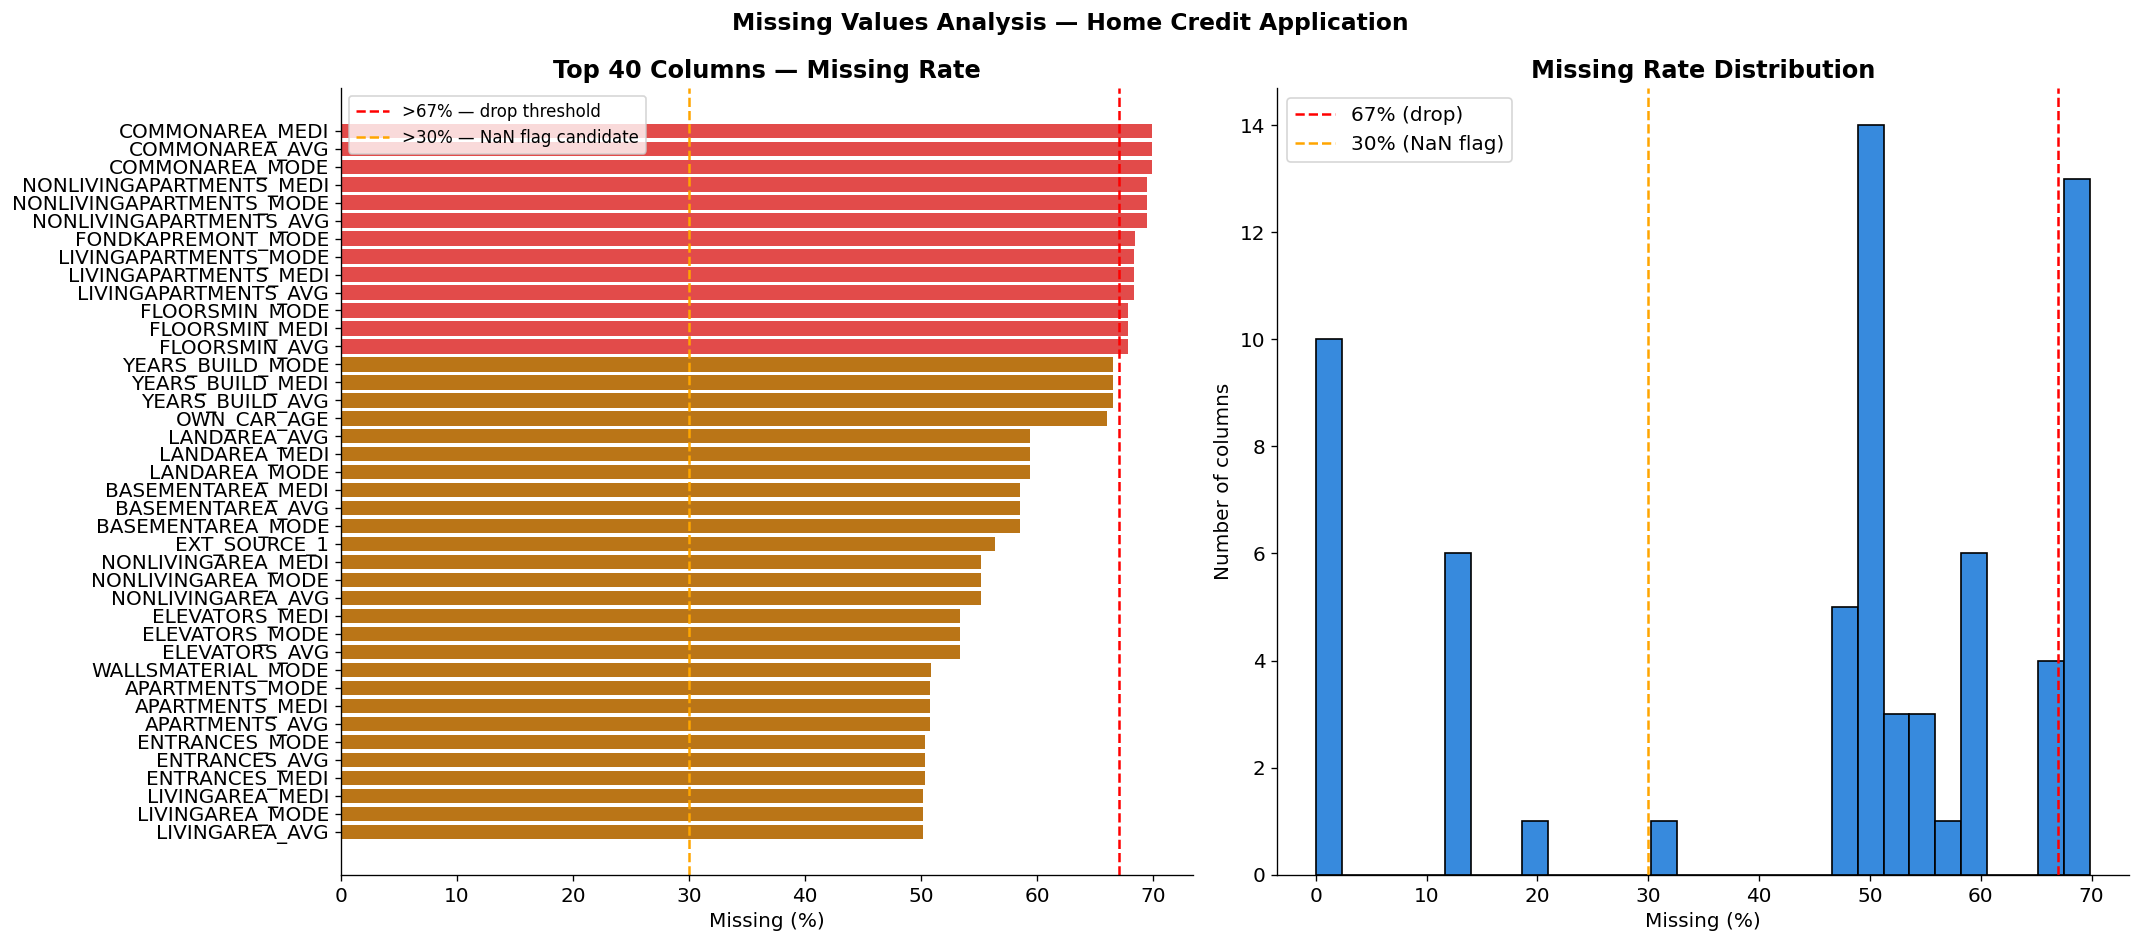

Saved: 02_missing/missing_overview.png

NaN flag candidates — default rate when missing vs not missing:
                column  missing_pct  default_NaN  default_val   lift
          EXT_SOURCE_3      19.8250       9.3120       7.7670 1.1990
           OWN_CAR_AGE      65.9910       8.5000       7.2440 1.1730
          EXT_SOURCE_1      56.3810       8.5200       7.4960 1.1370
          EXT_SOURCE_2       0.2150       7.8790       8.0730 0.9760
       AMT_GOODS_PRICE       0.0900       7.5540       8.0730 0.9360
           AMT_ANNUITY       0.0040       0.0000       8.0730 0.0000
DAYS_LAST_PHONE_CHANGE       0.0000       0.0000       8.0730 0.0000
       CNT_FAM_MEMBERS       0.0010       0.0000       8.0730 0.0000


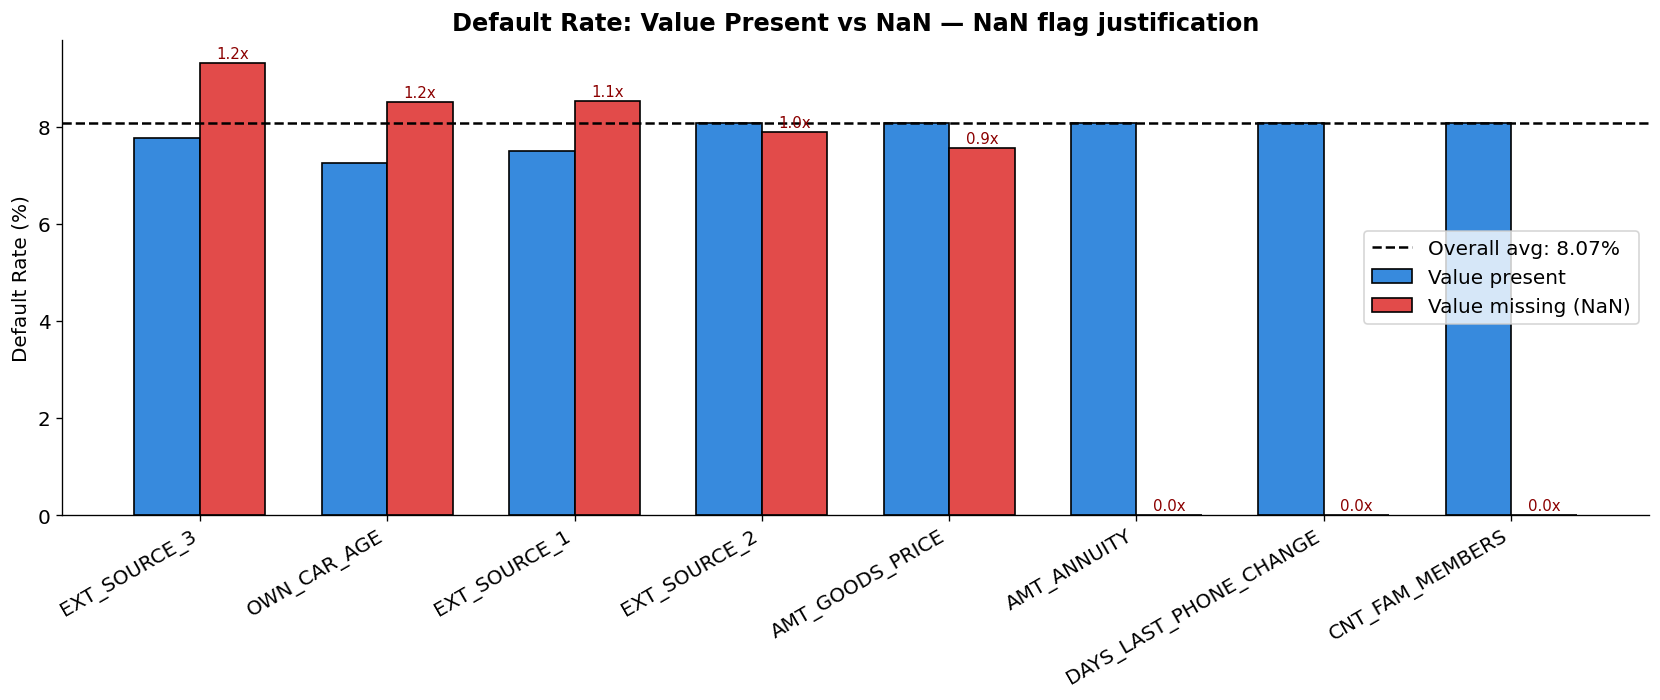

Saved: 02_missing/nan_flag_justification.png

Decision:
  DROP threshold  : >67% → 13 columns
  NaN flag cols   : ['EXT_SOURCE_3', 'OWN_CAR_AGE', 'EXT_SOURCE_1']


In [3]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct'  : df.isnull().mean() * 100,
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print('='*55)
print('MISSING VALUES SUMMARY')
print('='*55)
print(f'  Total columns              : {df.shape[1]}')
print(f'  Columns with any missing   : {len(missing)}')
print(f'  Columns >90% missing       : {(missing["missing_pct"] > 90).sum()}')
print(f'  Columns >67% missing       : {(missing["missing_pct"] > 67).sum()}  ← DROP threshold')
print(f'  Columns >50% missing       : {(missing["missing_pct"] > 50).sum()}')
print(f'  Columns >20% missing       : {(missing["missing_pct"] > 20).sum()}')

print(f'\nTop 30 most missing columns:')
print(missing.head(30).to_string())

print('\nMissing by column group:')
miss_groups = {
    'AMT_* columns'  : [c for c in df.columns if c.startswith('AMT_')],
    'DAYS_* columns' : [c for c in df.columns if c.startswith('DAYS_')],
    'FLAG_* columns' : [c for c in df.columns if c.startswith('FLAG_')],
    'EXT_SOURCE'     : [c for c in df.columns if c.startswith('EXT_SOURCE')],
    'Building _AVG'  : [c for c in df.columns if c.endswith('_AVG')],
    'Building _MODE' : [c for c in df.columns if c.endswith('_MODE')],
    'Building _MEDI' : [c for c in df.columns if c.endswith('_MEDI')],
}
for name, cols in miss_groups.items():
    if not cols: continue
    grp = df[cols].isnull().mean() * 100
    print(f'  {name:<20} | avg: {grp.mean():5.1f}% | max: {grp.max():5.1f}% | zero missing: {(grp==0).sum():>3}/{len(cols)}')

# ── Figure 1: Missing overview ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top40 = missing.head(40)
axes[0].barh(
    top40.index[::-1], top40['missing_pct'][::-1],
    color=[
        PALETTE['default']   if x > 67
        else PALETTE['highlight'] if x > 30
        else PALETTE['ok']
        for x in top40['missing_pct'][::-1]
    ]
)
axes[0].axvline(67, color='red',    ls='--', lw=1.5, label='>67% — drop threshold')
axes[0].axvline(30, color='orange', ls='--', lw=1.5, label='>30% — NaN flag candidate')
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Top 40 Columns — Missing Rate', fontweight='bold')
axes[0].legend(fontsize=10)

axes[1].hist(missing['missing_pct'], bins=30, color=PALETTE['ok'], edgecolor='black')
axes[1].axvline(67, color='red',    ls='--', lw=1.5, label='67% (drop)')
axes[1].axvline(30, color='orange', ls='--', lw=1.5, label='30% (NaN flag)')
axes[1].set_xlabel('Missing (%)')
axes[1].set_ylabel('Number of columns')
axes[1].set_title('Missing Rate Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Missing Values Analysis — Home Credit Application', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_missing' / 'missing_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_missing/missing_overview.png')

# ── Figure 2: NaN flag candidates — default rate analysis ────────────────────
nan_candidates = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
                  'OWN_CAR_AGE', 'AMT_GOODS_PRICE', 'AMT_ANNUITY',
                  'DAYS_LAST_PHONE_CHANGE', 'CNT_FAM_MEMBERS']
nan_candidates = [c for c in nan_candidates if c in df.columns]

nan_analysis = []
for col in nan_candidates:
    has_nan = df[col].isnull()
    dr_nan    = df.loc[has_nan,    'TARGET'].mean() * 100 if has_nan.sum() > 0 else 0
    dr_notnan = df.loc[~has_nan,   'TARGET'].mean() * 100
    nan_analysis.append({
        'column'      : col,
        'missing_pct' : has_nan.mean() * 100,
        'default_NaN' : dr_nan,
        'default_val' : dr_notnan,
        'lift'        : dr_nan / dr_notnan if dr_notnan > 0 else 0,
    })

nan_df = pd.DataFrame(nan_analysis).sort_values('lift', ascending=False)
print('\nNaN flag candidates — default rate when missing vs not missing:')
print(nan_df.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(nan_df))
w = 0.35
ax.bar(x - w/2, nan_df['default_val'], w, color=PALETTE['ok'],      label='Value present', edgecolor='black')
ax.bar(x + w/2, nan_df['default_NaN'], w, color=PALETTE['default'], label='Value missing (NaN)', edgecolor='black')
ax.axhline(df['TARGET'].mean() * 100, color='black', ls='--', lw=1.5,
           label=f'Overall avg: {df["TARGET"].mean()*100:.2f}%')
ax.set_xticks(x)
ax.set_xticklabels(nan_df['column'], rotation=30, ha='right')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate: Value Present vs NaN — NaN flag justification', fontweight='bold')
ax.legend()
for i, row in enumerate(nan_df.itertuples()):
    ax.text(i + w/2, row.default_NaN + 0.1, f'{row.lift:.1f}x', ha='center', fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig(FIG_DIR / '02_missing' / 'nan_flag_justification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_missing/nan_flag_justification.png')

# Decision
to_drop_cols  = missing[missing['missing_pct'] > 67].index.tolist()
nan_flag_cols = nan_df[nan_df['lift'] > 1.05]['column'].tolist()
print(f'\nDecision:')
print(f'  DROP threshold  : >67% → {len(to_drop_cols)} columns')
print(f'  NaN flag cols   : {nan_flag_cols}')


---
## 3. Target Variable Analysis

Class imbalance of 11.4:1 dictates the modeling strategy.


TARGET VARIABLE — Credit Default
  No Default (0) :   282,686  (91.93%)
  Default    (1) :    24,825  (8.07%)
  Imbalance ratio: 11.4:1
  scale_pos_weight (XGBoost) : 11


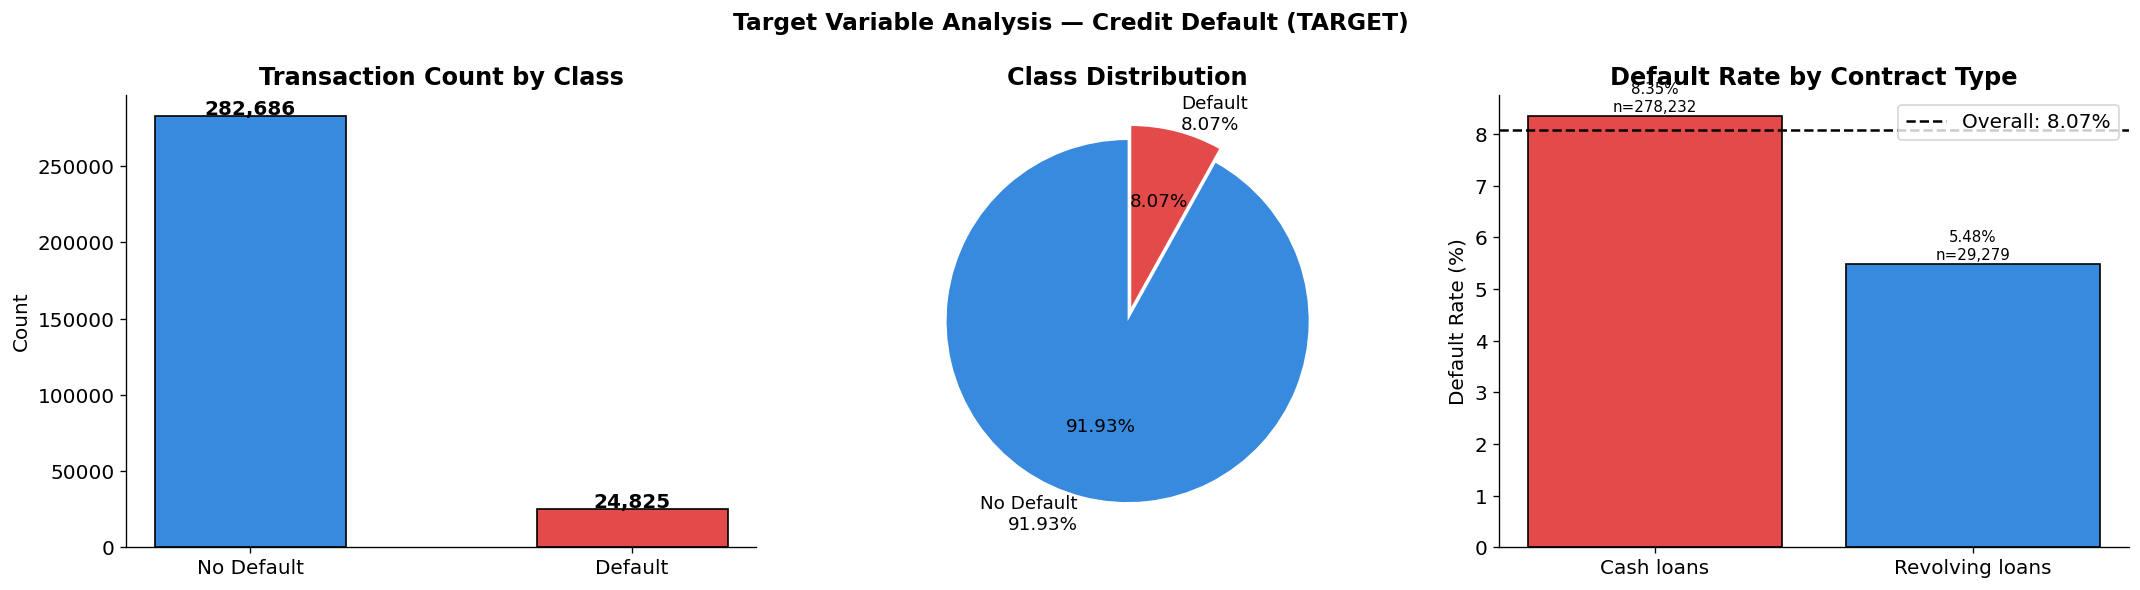

Saved: 01_target/target_overview.png

Key insights:
  scale_pos_weight = 11  (XGBoost)
  is_unbalance = True             (LightGBM)
  auto_class_weights = 'Balanced' (CatBoost)
  Cash loans default: 8.35%
  Revolving loans   : 5.48%


In [4]:
print('='*50)
print('TARGET VARIABLE — Credit Default')
print('='*50)
print(f'  No Default (0) : {len(ok):>9,}  ({len(ok)/len(df)*100:.2f}%)')
print(f'  Default    (1) : {len(default):>9,}  ({len(default)/len(df)*100:.2f}%)')
print(f'  Imbalance ratio: {len(ok)/len(default):.1f}:1')
print(f'  scale_pos_weight (XGBoost) : {len(ok)/len(default):.0f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar
axes[0].bar(
    ['No Default', 'Default'], [len(ok), len(default)],
    color=[PALETTE['ok'], PALETTE['default']], edgecolor='black', width=0.5
)
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([len(ok), len(default)]):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(
    [len(ok), len(default)],
    labels=['No Default\n91.93%', 'Default\n8.07%'],
    colors=[PALETTE['ok'], PALETTE['default']],
    autopct='%1.2f%%', startangle=90,
    explode=(0, 0.08), textprops={'fontsize': 11}
)
axes[1].set_title('Class Distribution', fontweight='bold')

# Default rate by contract type
ct_stats = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].agg(
    default_rate='mean', count='count'
).reset_index()
ct_stats['default_rate'] = ct_stats['default_rate'] * 100
axes[2].bar(ct_stats['NAME_CONTRACT_TYPE'], ct_stats['default_rate'],
            color=[PALETTE['default'] if r > df['TARGET'].mean()*100 else PALETTE['ok']
                   for r in ct_stats['default_rate']],
            edgecolor='black')
axes[2].axhline(df['TARGET'].mean()*100, color='black', ls='--', lw=1.5,
                label=f'Overall: {df["TARGET"].mean()*100:.2f}%')
axes[2].set_ylabel('Default Rate (%)')
axes[2].set_title('Default Rate by Contract Type', fontweight='bold')
axes[2].legend()
for i, row in enumerate(ct_stats.itertuples()):
    axes[2].text(i, row.default_rate + 0.1, f'{row.default_rate:.2f}%\nn={row.count:,}',
                 ha='center', fontsize=9)

plt.suptitle('Target Variable Analysis — Credit Default (TARGET)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_target' / 'target_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_target/target_overview.png')

print(f'\nKey insights:')
print(f'  scale_pos_weight = {len(ok)/len(default):.0f}  (XGBoost)')
print(f'  is_unbalance = True             (LightGBM)')
print(f"  auto_class_weights = 'Balanced' (CatBoost)")
print(f'  Cash loans default: {df[df["NAME_CONTRACT_TYPE"]=="Cash loans"]["TARGET"].mean()*100:.2f}%')
print(f'  Revolving loans   : {df[df["NAME_CONTRACT_TYPE"]=="Revolving loans"]["TARGET"].mean()*100:.2f}%')


---
## 4. Loan Amount Analysis

`AMT_INCOME_TOTAL` extreme right-skewed → log1p transformation needed.  
Credit-to-income and annuity-to-income ratios are key feature engineering signals.


LOAN AMOUNT ANALYSIS

Basic statistics:
       AMT_INCOME_TOTAL   AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE
count       307511.0000  307511.0000  307499.0000      307233.0000
mean        168797.9200  599026.0000   27108.5700      538396.2100
std         237123.1500  402490.7800   14493.7400      369446.4600
min          25650.0000   45000.0000    1615.5000       40500.0000
25%         112500.0000  270000.0000   16524.0000      238500.0000
50%         147150.0000  513531.0000   24903.0000      450000.0000
75%         202500.0000  808650.0000   34596.0000      679500.0000
max      117000000.0000 4050000.0000  258025.5000     4050000.0000

Skewness (raw vs log1p):
  AMT_INCOME_TOTAL          raw: 391.56  →  log1p:   0.17
  AMT_CREDIT                raw:   1.23  →  log1p:  -0.34
  AMT_ANNUITY               raw:   1.58  →  log1p:  -0.35
  AMT_GOODS_PRICE           raw:   1.35  →  log1p:  -0.29

Default vs No Default — mean comparison:
  AMT_INCOME_TOTAL          No Default:    169,078  |  De

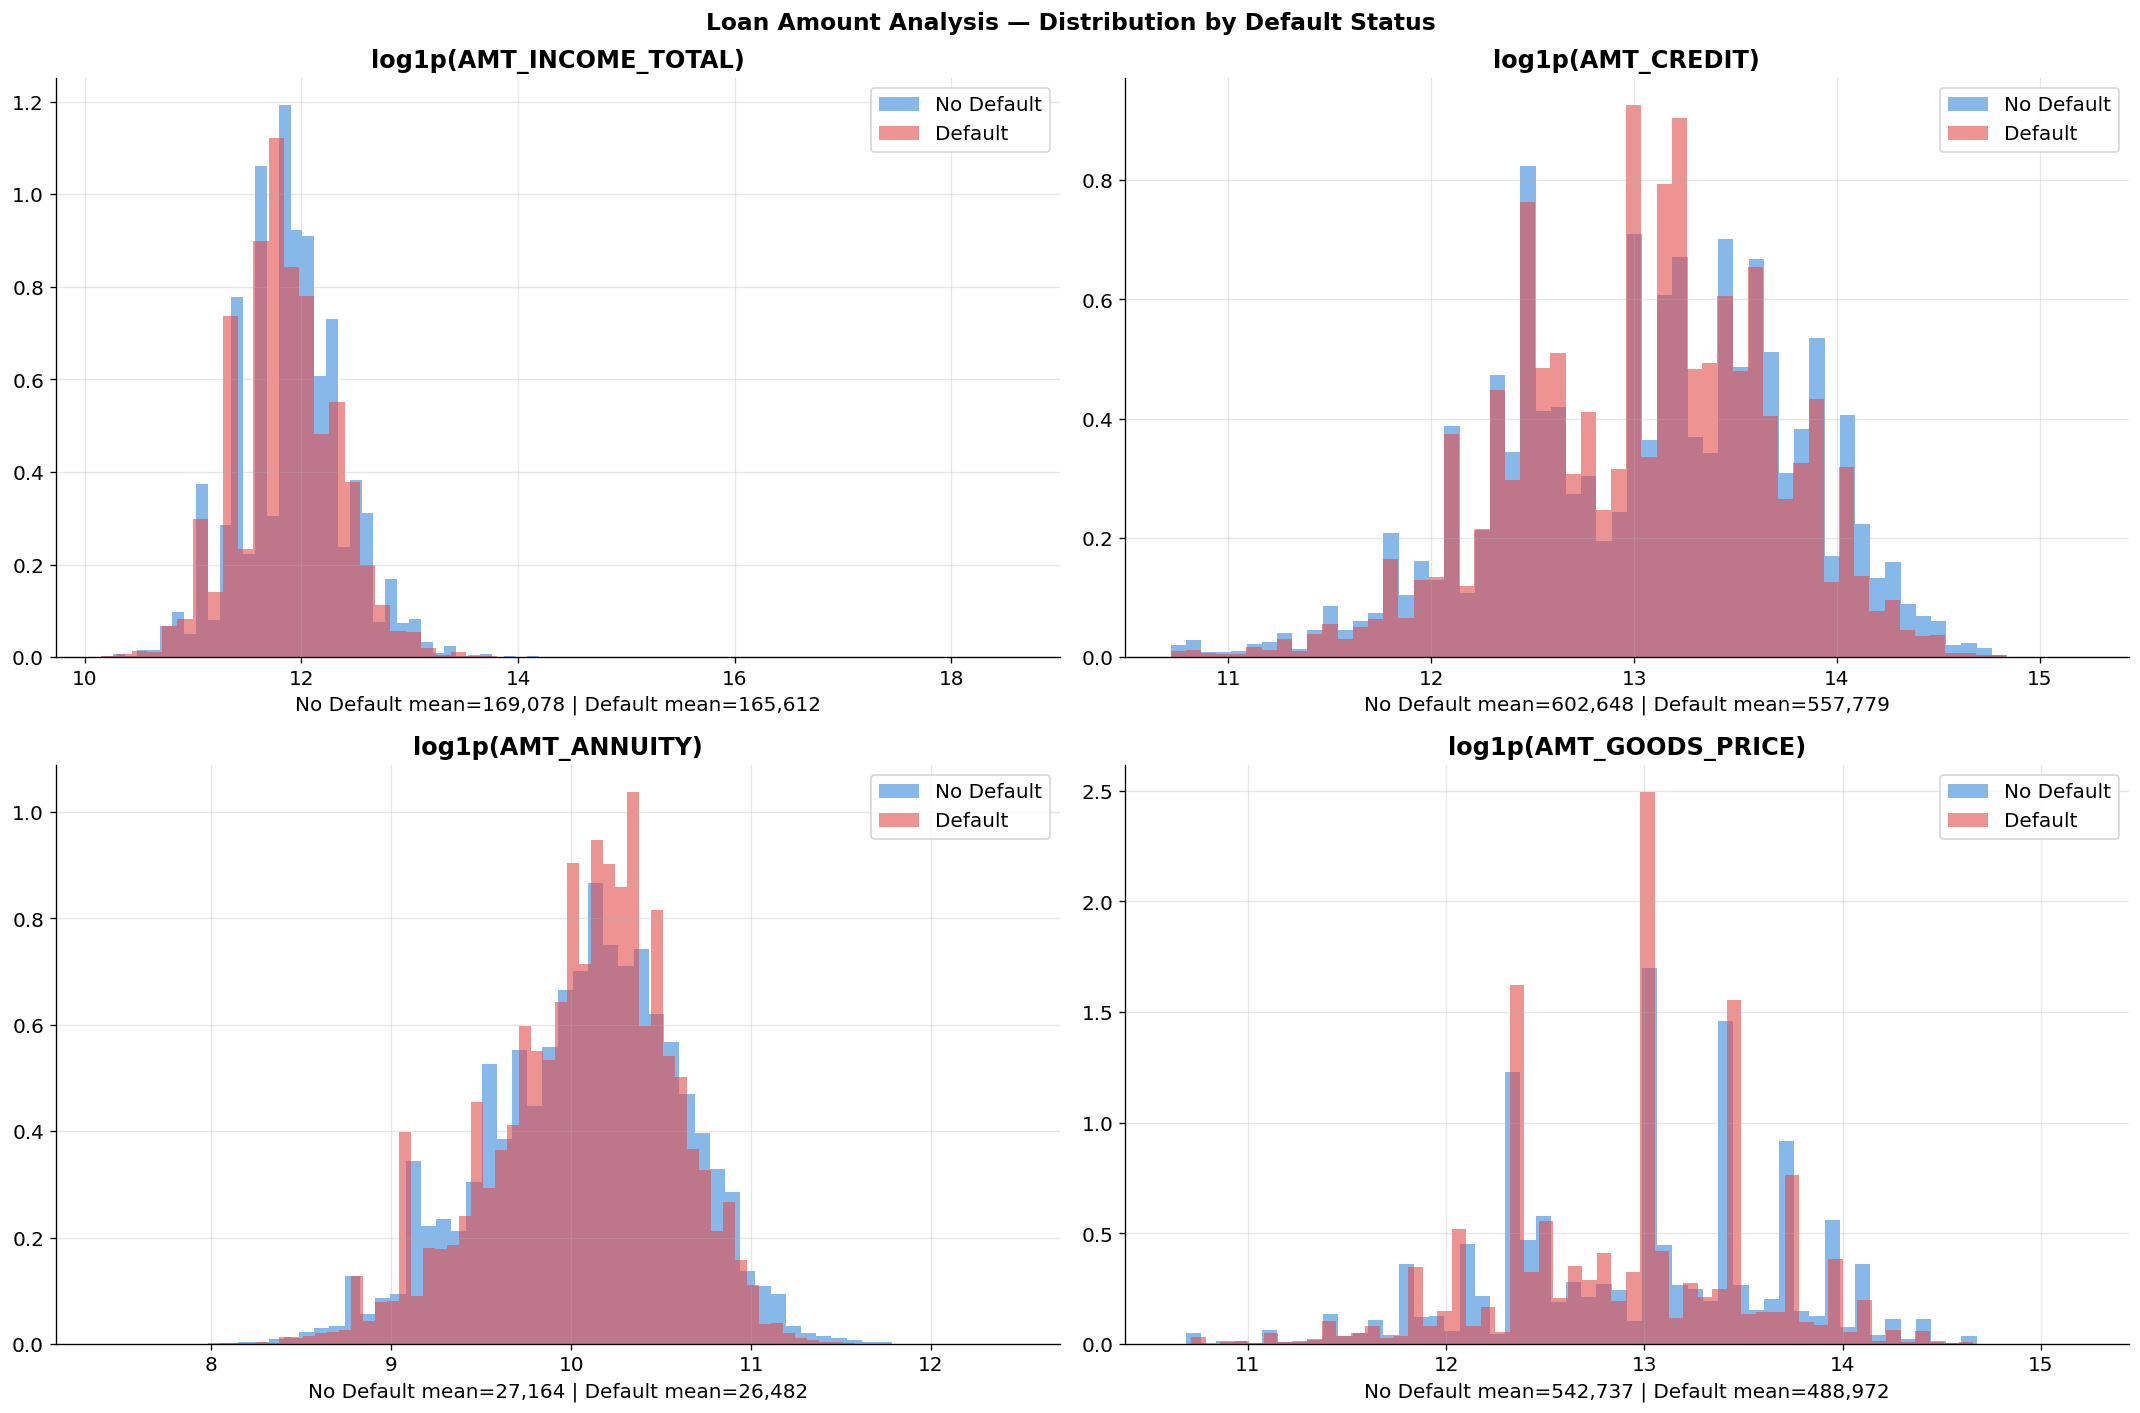

Saved: 03_amounts/amount_distributions.png

Ratio features — Default vs No Default:
  _credit_income_ratio           No Default: 3.9637  Default: 3.8874  corr: -0.0077
  _annuity_income_ratio          No Default: 0.1805  Default: 0.1855  corr: 0.0143
  _annuity_credit_ratio          No Default: 0.0536  Default: 0.0547  corr: 0.0127
  _credit_goods_ratio            No Default: 1.1204  Default: 1.1521  corr: 0.0694


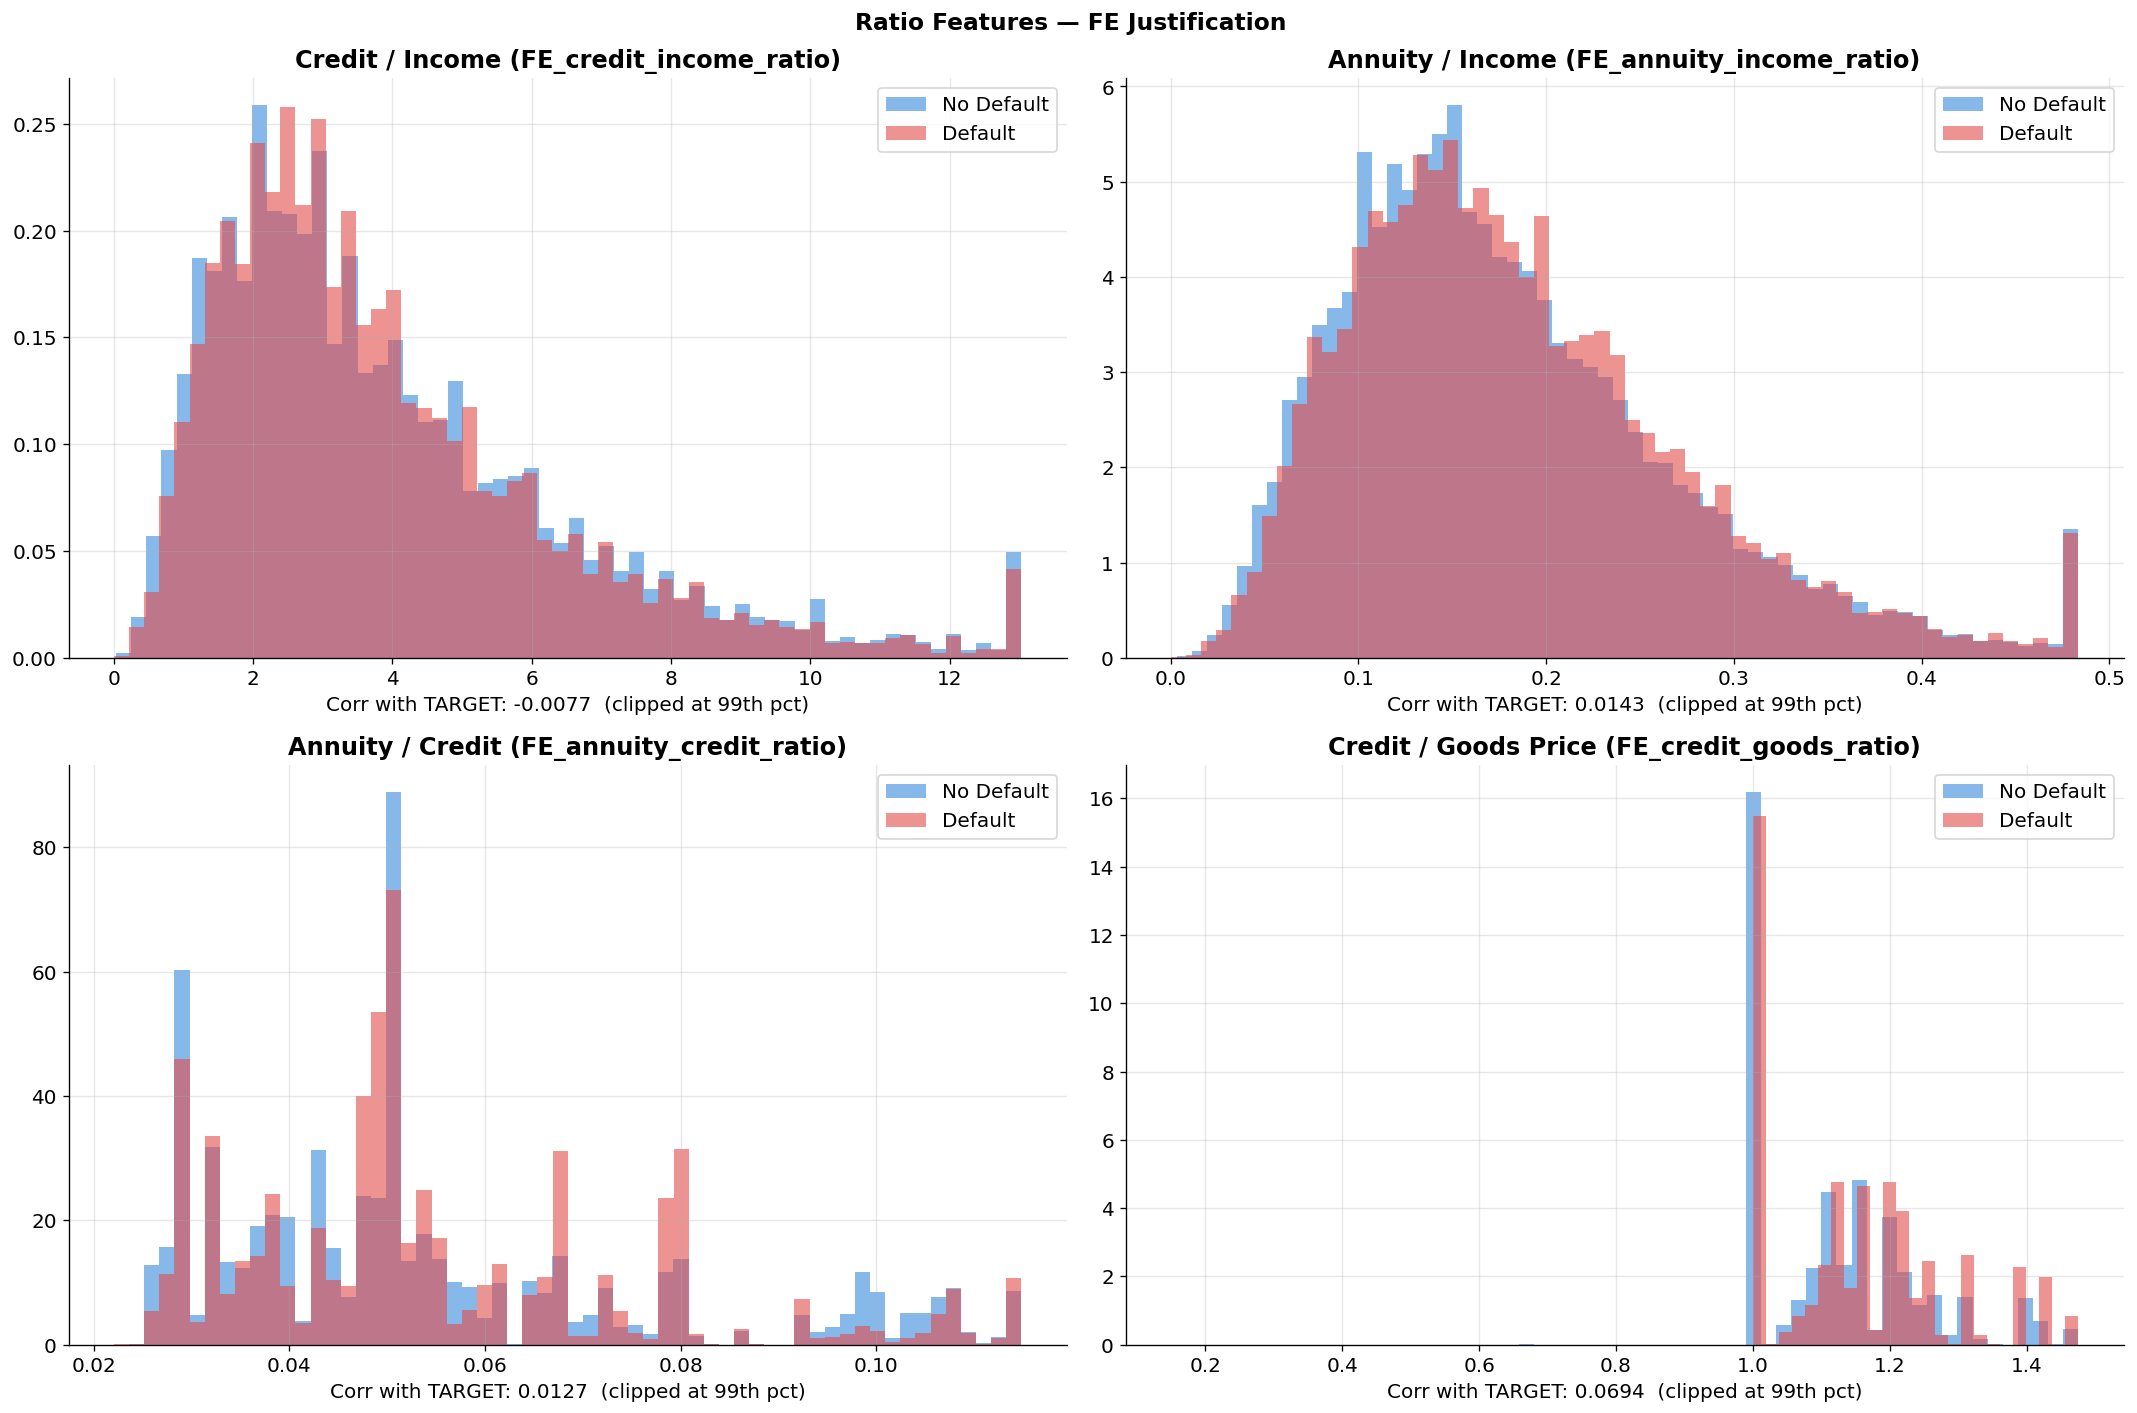

Saved: 03_amounts/ratio_features.png


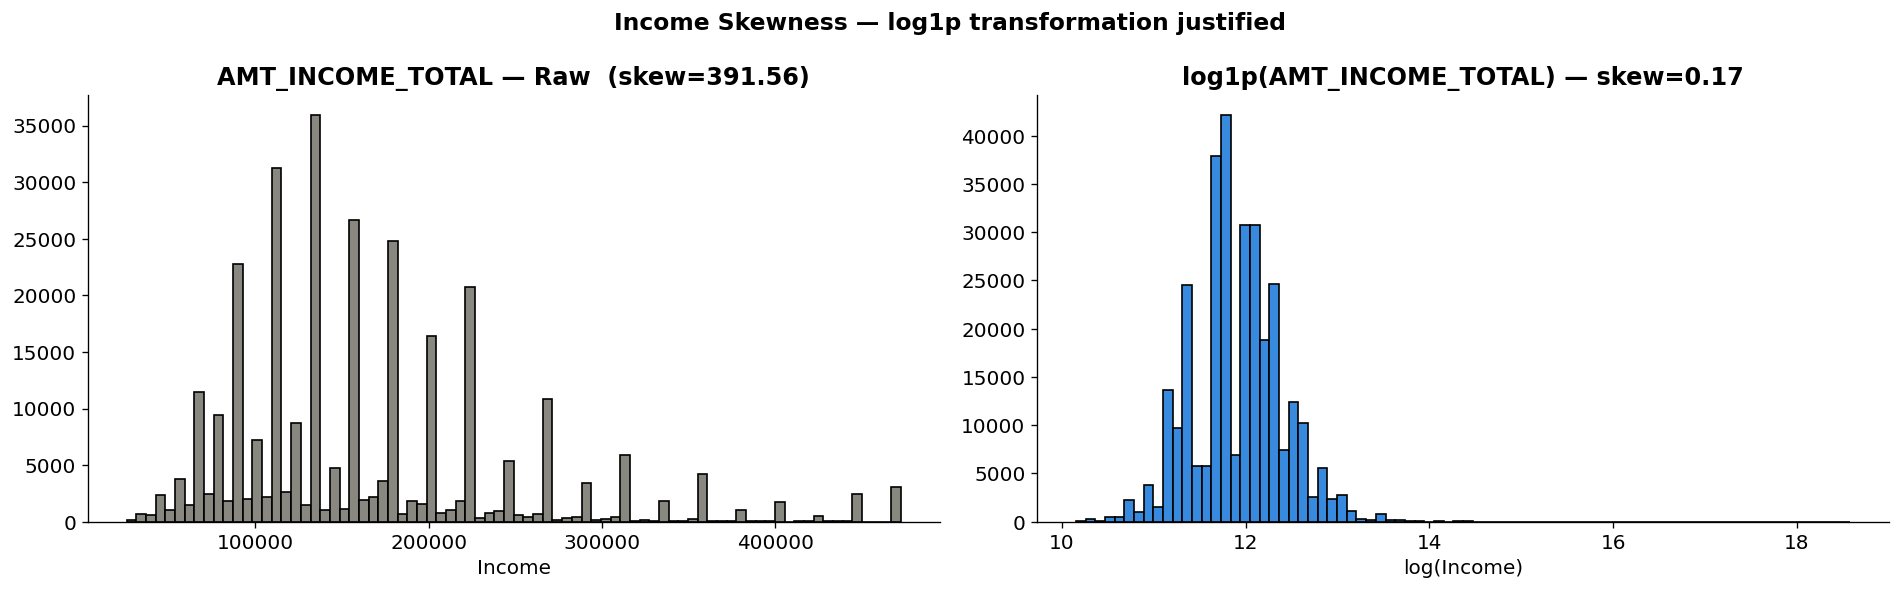

Saved: 03_amounts/income_skewness.png


In [5]:
print('='*55)
print('LOAN AMOUNT ANALYSIS')
print('='*55)

amt_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
print('\nBasic statistics:')
print(df[amt_cols].describe().round(2))

print('\nSkewness (raw vs log1p):')
for col in amt_cols:
    raw_skew = df[col].skew()
    log_skew = np.log1p(df[col]).skew()
    print(f'  {col:<25} raw: {raw_skew:6.2f}  →  log1p: {log_skew:6.2f}')

print('\nDefault vs No Default — mean comparison:')
for col in amt_cols:
    m0 = df[df['TARGET']==0][col].mean()
    m1 = df[df['TARGET']==1][col].mean()
    print(f'  {col:<25} No Default: {m0:>10,.0f}  |  Default: {m1:>10,.0f}  |  ratio: {m1/m0:.3f}')

# ── Figure 1: Amount distributions ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for idx, col in enumerate(amt_cols):
    ax = axes[idx//2, idx%2]
    d0 = np.log1p(df[df['TARGET']==0][col].dropna())
    d1 = np.log1p(df[df['TARGET']==1][col].dropna())
    ax.hist(d0, bins=60, alpha=0.6, label='No Default', color=PALETTE['ok'],      density=True)
    ax.hist(d1, bins=60, alpha=0.6, label='Default',    color=PALETTE['default'], density=True)
    ax.set_title(f'log1p({col})', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    m0 = df[df['TARGET']==0][col].mean()
    m1 = df[df['TARGET']==1][col].mean()
    ax.set_xlabel(f'No Default mean={m0:,.0f} | Default mean={m1:,.0f}')

plt.suptitle('Loan Amount Analysis — Distribution by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_amounts' / 'amount_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_amounts/amount_distributions.png')

# ── Figure 2: Ratio features ──────────────────────────────────────────────────
df['_credit_income_ratio']   = df['AMT_CREDIT']  / (df['AMT_INCOME_TOTAL'] + 1)
df['_annuity_income_ratio']  = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
df['_annuity_credit_ratio']  = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
df['_credit_goods_ratio']    = df['AMT_CREDIT']  / (df['AMT_GOODS_PRICE'] + 1)

ratio_cols = ['_credit_income_ratio', '_annuity_income_ratio',
              '_annuity_credit_ratio', '_credit_goods_ratio']

print('\nRatio features — Default vs No Default:')
for col in ratio_cols:
    m0 = df[df['TARGET']==0][col].mean()
    m1 = df[df['TARGET']==1][col].mean()
    corr = df[col].corr(df['TARGET'])
    print(f'  {col:<30} No Default: {m0:.4f}  Default: {m1:.4f}  corr: {corr:.4f}')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
labels_map = {
    '_credit_income_ratio'  : 'Credit / Income (FE_credit_income_ratio)',
    '_annuity_income_ratio' : 'Annuity / Income (FE_annuity_income_ratio)',
    '_annuity_credit_ratio' : 'Annuity / Credit (FE_annuity_credit_ratio)',
    '_credit_goods_ratio'   : 'Credit / Goods Price (FE_credit_goods_ratio)',
}
for idx, col in enumerate(ratio_cols):
    ax = axes[idx//2, idx%2]
    clip_val = df[col].quantile(0.99)
    d0 = df[df['TARGET']==0][col].clip(upper=clip_val)
    d1 = df[df['TARGET']==1][col].clip(upper=clip_val)
    ax.hist(d0, bins=60, alpha=0.6, label='No Default', color=PALETTE['ok'],      density=True)
    ax.hist(d1, bins=60, alpha=0.6, label='Default',    color=PALETTE['default'], density=True)
    ax.set_title(labels_map[col], fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    corr = df[col].corr(df['TARGET'])
    ax.set_xlabel(f'Corr with TARGET: {corr:.4f}  (clipped at 99th pct)')

plt.suptitle('Ratio Features — FE Justification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_amounts' / 'ratio_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_amounts/ratio_features.png')

# ── Figure 3: Income distribution (raw skewness) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(df['AMT_INCOME_TOTAL'].clip(upper=df['AMT_INCOME_TOTAL'].quantile(0.99)),
             bins=80, color=PALETTE['neutral'], edgecolor='black')
axes[0].set_title(f'AMT_INCOME_TOTAL — Raw  (skew={df["AMT_INCOME_TOTAL"].skew():.2f})', fontweight='bold')
axes[0].set_xlabel('Income')

axes[1].hist(np.log1p(df['AMT_INCOME_TOTAL']), bins=80, color=PALETTE['ok'], edgecolor='black')
axes[1].set_title(f'log1p(AMT_INCOME_TOTAL) — skew={np.log1p(df["AMT_INCOME_TOTAL"]).skew():.2f}', fontweight='bold')
axes[1].set_xlabel('log(Income)')

plt.suptitle('Income Skewness — log1p transformation justified', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_amounts' / 'income_skewness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_amounts/income_skewness.png')


---
## 5. Categorical Features Analysis

Key categorical predictors: income type (maternity leave=40%), education, housing, gender.


CATEGORICAL FEATURES — DEFAULT RATE ANALYSIS

NAME_CONTRACT_TYPE:
                     mean   count
NAME_CONTRACT_TYPE               
Cash loans         8.3460  278232
Revolving loans    5.4780   29279

CODE_GENDER:
               mean   count
CODE_GENDER                
M           10.1420  105059
F            6.9990  202448
XNA          0.0000       4

NAME_INCOME_TYPE:
                        mean   count
NAME_INCOME_TYPE                    
Maternity leave      40.0000       5
Unemployed           36.3640      22
Working               9.5880  158774
Commercial associate  7.4840   71617
State servant         5.7550   21703
Pensioner             5.3860   55362
Businessman           0.0000      10
Student               0.0000      18

NAME_EDUCATION_TYPE:
                                 mean   count
NAME_EDUCATION_TYPE                          
Lower secondary               10.9280    3816
Secondary / secondary special  8.9400  218391
Incomplete higher              8.4850   10277
Hig

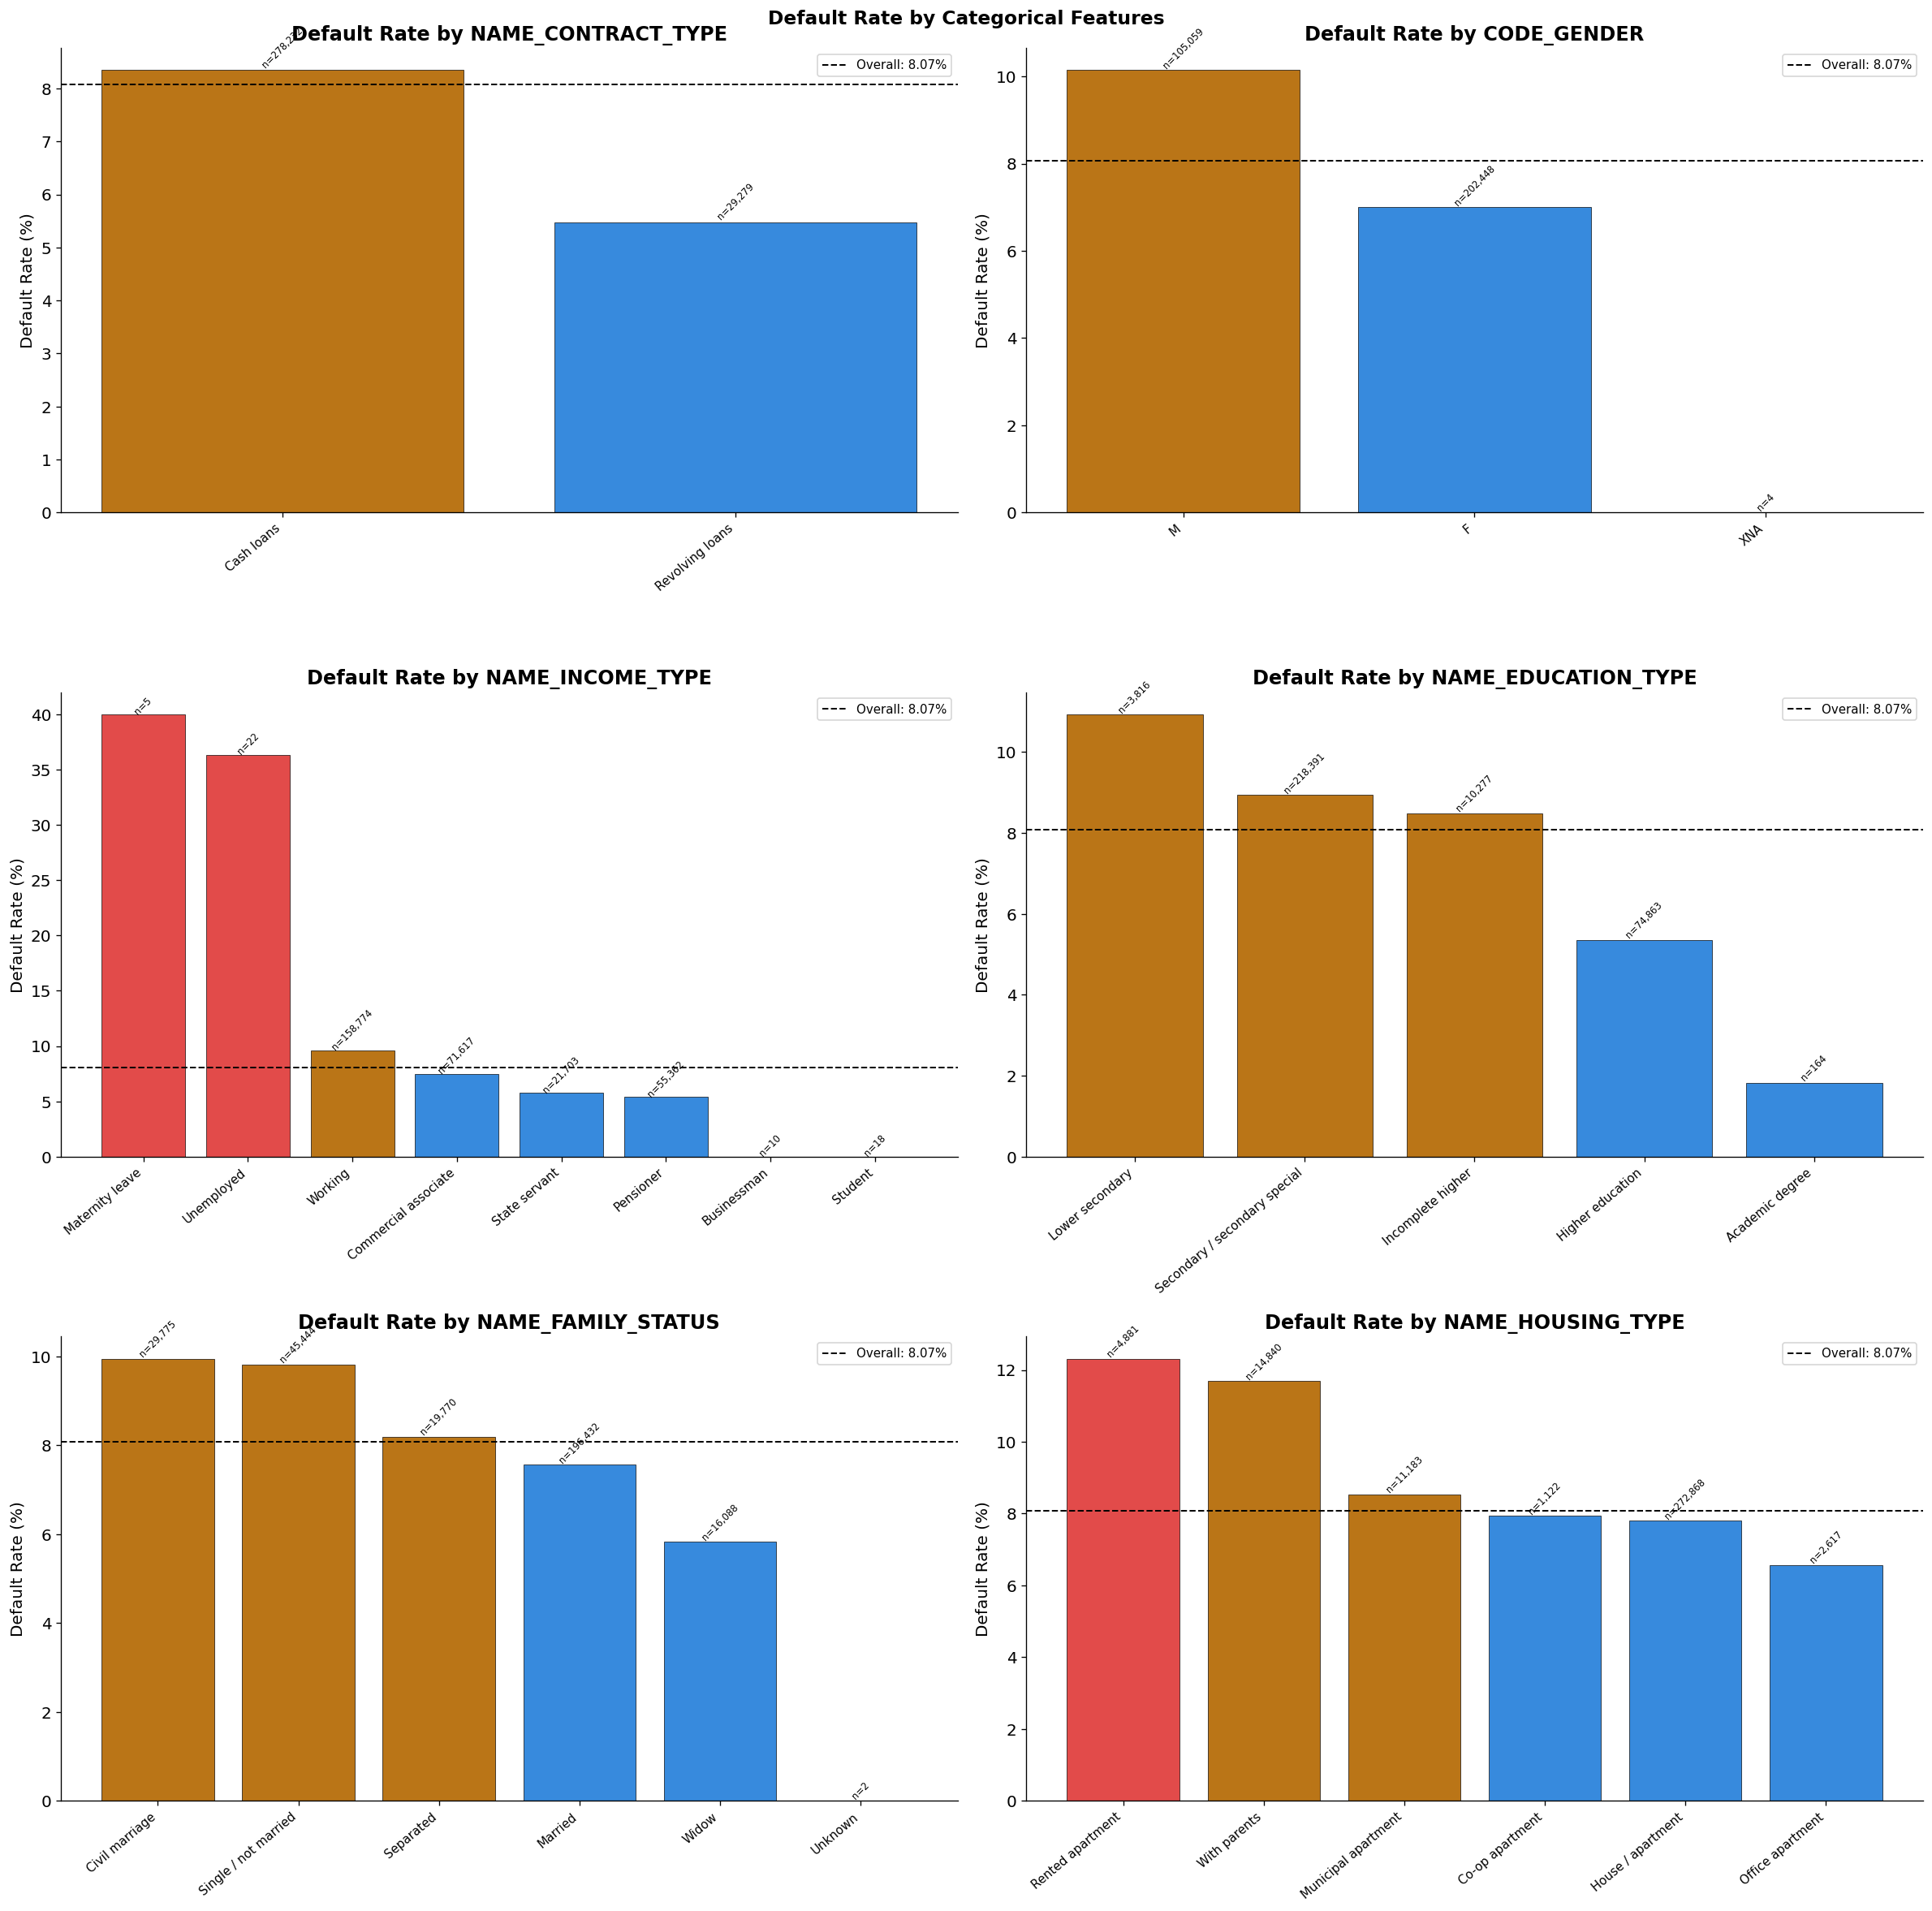

Saved: 04_categorical/categorical_default_rates.png


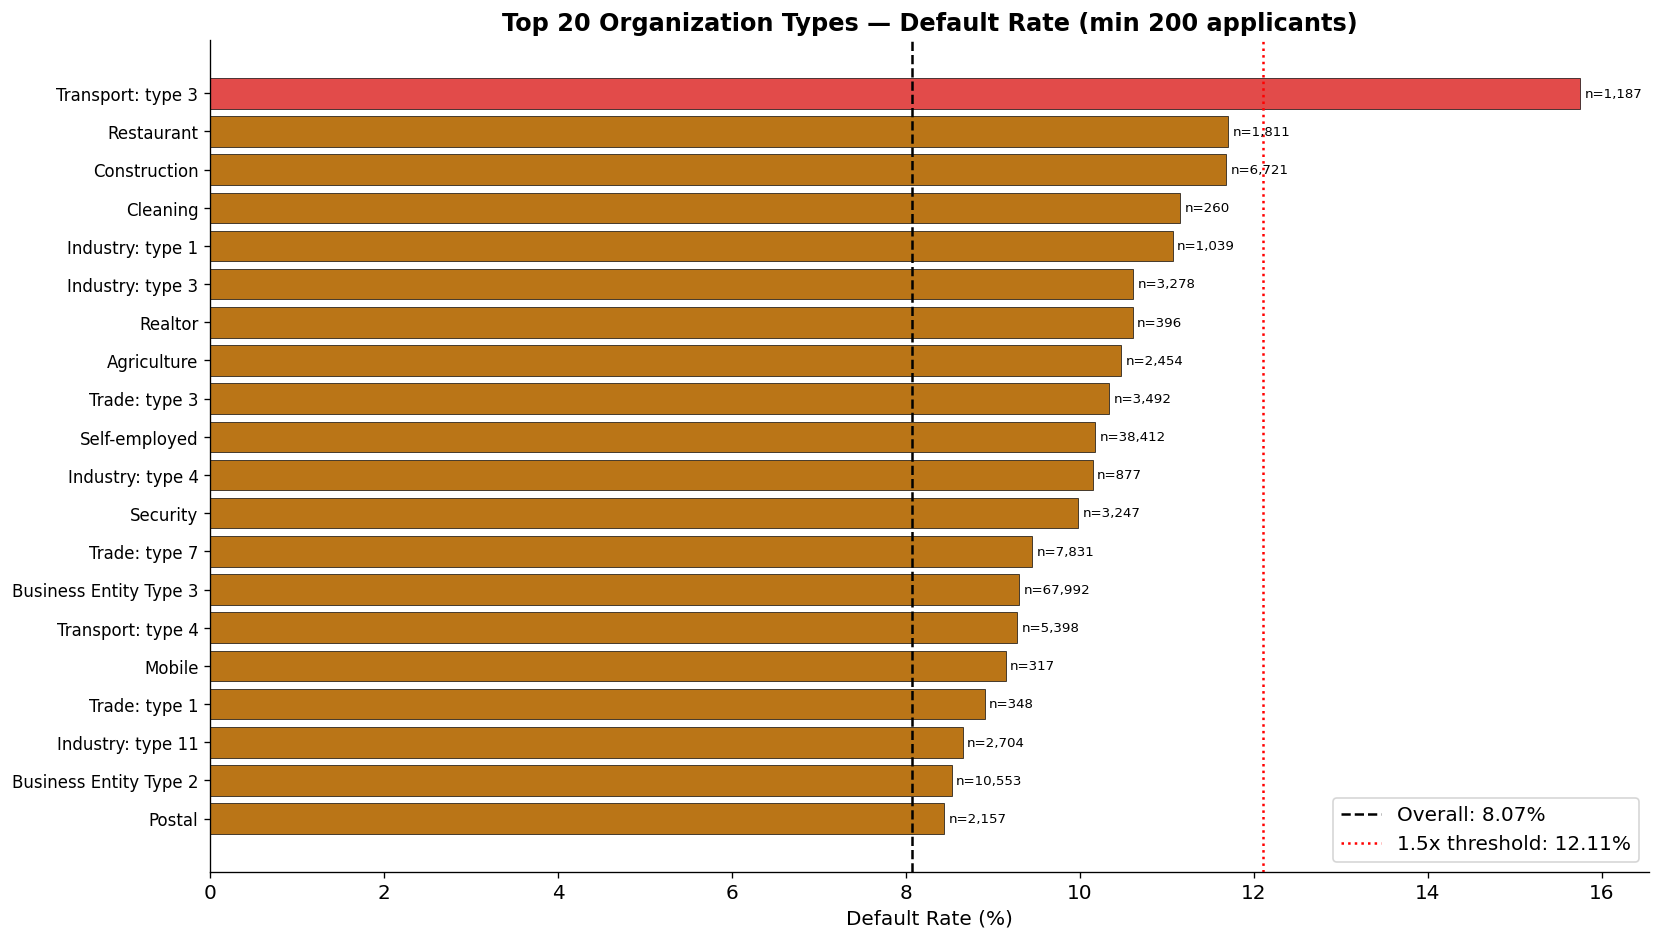

Saved: 04_categorical/organization_type_default.png

OCCUPATION_TYPE missing: 31.3%
      OCCUPATION_TYPE  default_rate  count
   Low-skill Laborers       17.1524   2093
              Drivers       11.3261  18603
 Waiters/barmen staff       11.2760   1348
       Security staff       10.7424   6721
             Laborers       10.5788  55186
        Cooking staff       10.4440   5946
          Sales staff        9.6318  32102
       Cleaning staff        9.6067   4653
        Realty agents        7.8562    751
          Secretaries        7.0498   1305
       Medicine staff        6.7002   8537
Private service staff        6.5988   2652
             IT staff        6.4639    526
             HR staff        6.3943    563
           Core staff        6.3040  27570
             Managers        6.2140  21371
High skill tech staff        6.1599  11380
          Accountants        4.8303   9813


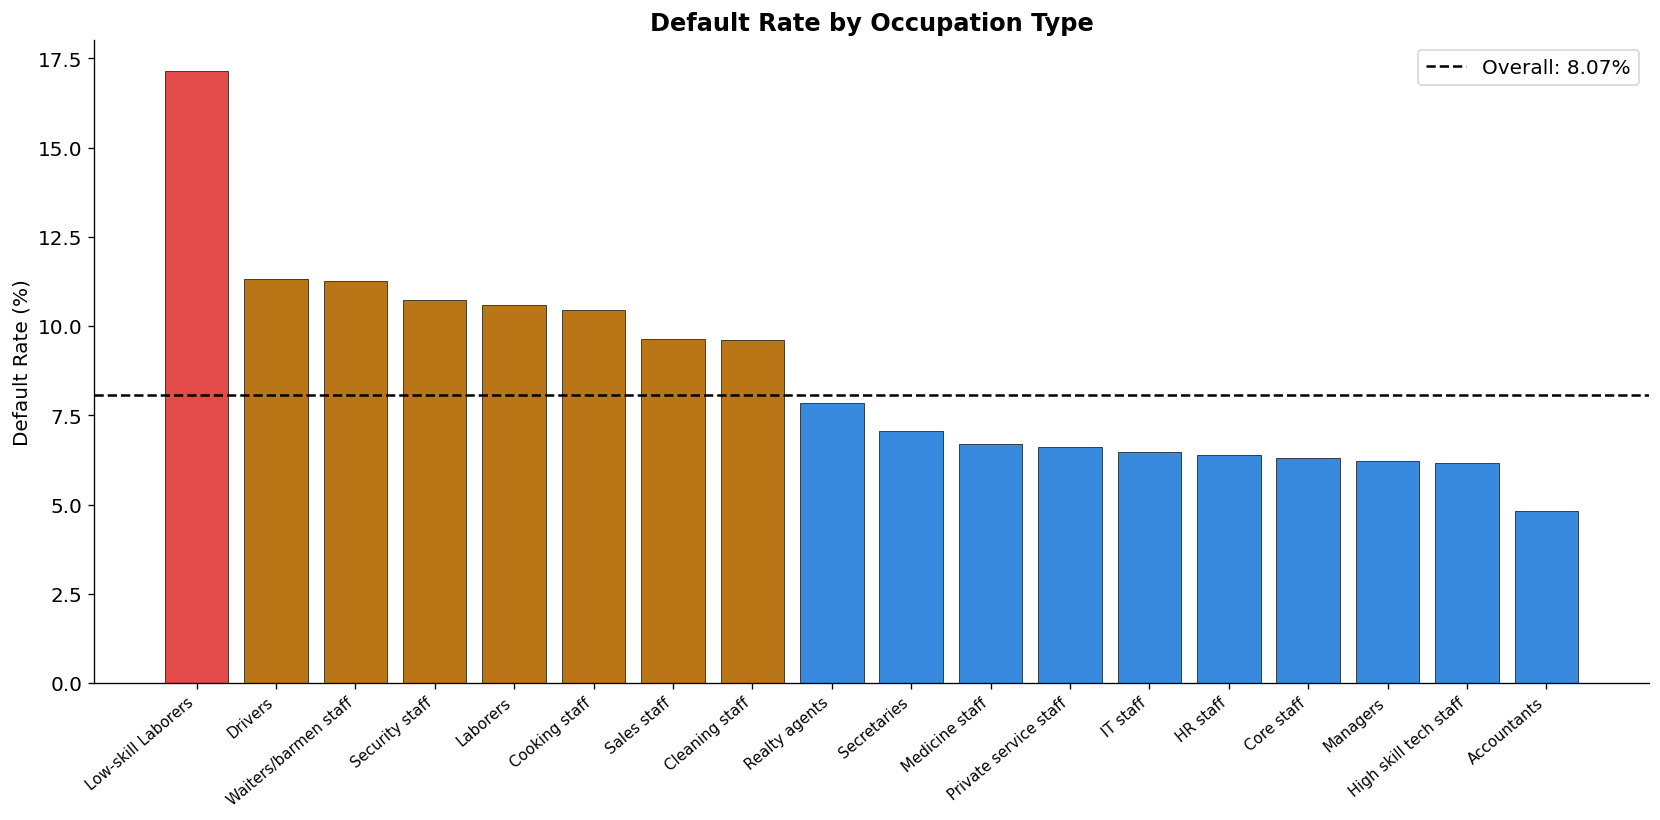

Saved: 04_categorical/occupation_type_default.png

Frequency encoding candidates (high cardinality):
  ORGANIZATION_TYPE              unique:  58 | missing: 0.0%
  OCCUPATION_TYPE                unique:  18 | missing: 31.3%
  NAME_INCOME_TYPE               unique:   8 | missing: 0.0%
  NAME_EDUCATION_TYPE            unique:   5 | missing: 0.0%
  NAME_HOUSING_TYPE              unique:   6 | missing: 0.0%
  NAME_FAMILY_STATUS             unique:   6 | missing: 0.0%
Decision: frequency encoding for these 6 columns (FE_*_freq)


In [6]:
print('='*55)
print('CATEGORICAL FEATURES — DEFAULT RATE ANALYSIS')
print('='*55)

overall_dr = df['TARGET'].mean() * 100
cat_cols_main = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE'
]

for col in cat_cols_main:
    print(f'\n{col}:')
    stats = df.groupby(col)['TARGET'].agg(['mean','count']).sort_values('mean', ascending=False)
    stats['mean'] = (stats['mean'] * 100).round(3)
    print(stats.to_string())

# ── Figure 1: Main categorical default rates ──────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(20, 20))
axes = axes.flatten()

for idx, col in enumerate(cat_cols_main):
    stats = df.groupby(col)['TARGET'].agg(
        default_rate='mean', count='count'
    ).reset_index()
    stats['default_rate'] = stats['default_rate'] * 100
    stats = stats.sort_values('default_rate', ascending=False).reset_index(drop=True)

    colors = [
        PALETTE['default']   if r > overall_dr * 1.5
        else PALETTE['highlight'] if r > overall_dr
        else PALETTE['ok']
        for r in stats['default_rate']
    ]
    bars = axes[idx].bar(range(len(stats)), stats['default_rate'],
                         color=colors, edgecolor='black', linewidth=0.4)
    axes[idx].set_xticks(range(len(stats)))
    axes[idx].set_xticklabels(stats[col].astype(str), rotation=40, ha='right', fontsize=9)
    axes[idx].axhline(overall_dr, color='black', ls='--', lw=1.2,
                      label=f'Overall: {overall_dr:.2f}%')
    axes[idx].set_title(f'Default Rate by {col}', fontweight='bold')
    axes[idx].set_ylabel('Default Rate (%)')
    axes[idx].legend(fontsize=9)
    for bar, row in zip(bars, stats.itertuples()):
        axes[idx].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.05,
                       f'n={row.count:,}', ha='center', fontsize=7, rotation=45)

plt.suptitle('Default Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_categorical' / 'categorical_default_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_categorical/categorical_default_rates.png')

# ── Figure 2: ORGANIZATION_TYPE — top 20 by default rate ─────────────────────
org_stats = df.groupby('ORGANIZATION_TYPE')['TARGET'].agg(
    default_rate='mean', count='count'
).reset_index()
org_stats['default_rate'] = org_stats['default_rate'] * 100
org_top = org_stats[org_stats['count'] >= 200].sort_values('default_rate', ascending=False).head(20).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 8))
colors_org = [
    PALETTE['default']   if r > overall_dr * 1.5
    else PALETTE['highlight'] if r > overall_dr
    else PALETTE['ok']
    for r in org_top['default_rate']
]
ax.barh(range(len(org_top)), org_top['default_rate'],
        color=colors_org, edgecolor='black', linewidth=0.4)
ax.set_yticks(range(len(org_top)))
ax.set_yticklabels(org_top['ORGANIZATION_TYPE'], fontsize=10)
ax.axvline(overall_dr, color='black', ls='--', lw=1.5,
           label=f'Overall: {overall_dr:.2f}%')
ax.axvline(overall_dr * 1.5, color='red', ls=':', lw=1.5,
           label=f'1.5x threshold: {overall_dr*1.5:.2f}%')
ax.invert_yaxis()
ax.set_xlabel('Default Rate (%)')
ax.set_title('Top 20 Organization Types — Default Rate (min 200 applicants)', fontweight='bold')
ax.legend()
for bar, cnt in zip(ax.patches, org_top['count']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'n={cnt:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / '04_categorical' / 'organization_type_default.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_categorical/organization_type_default.png')

# ── Figure 3: OCCUPATION_TYPE ─────────────────────────────────────────────────
occ_stats = df.groupby('OCCUPATION_TYPE')['TARGET'].agg(
    default_rate='mean', count='count'
).reset_index()
occ_stats['default_rate'] = occ_stats['default_rate'] * 100
occ_stats = occ_stats.sort_values('default_rate', ascending=False).reset_index(drop=True)

print(f'\nOCCUPATION_TYPE missing: {df["OCCUPATION_TYPE"].isnull().mean()*100:.1f}%')
print(occ_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 7))
colors_occ = [
    PALETTE['default']   if r > overall_dr * 1.5
    else PALETTE['highlight'] if r > overall_dr
    else PALETTE['ok']
    for r in occ_stats['default_rate']
]
bars = ax.bar(range(len(occ_stats)), occ_stats['default_rate'],
              color=colors_occ, edgecolor='black', linewidth=0.4)
ax.set_xticks(range(len(occ_stats)))
ax.set_xticklabels(occ_stats['OCCUPATION_TYPE'], rotation=40, ha='right', fontsize=9)
ax.axhline(overall_dr, color='black', ls='--', lw=1.5,
           label=f'Overall: {overall_dr:.2f}%')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Occupation Type', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '04_categorical' / 'occupation_type_default.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_categorical/occupation_type_default.png')

# Frequency encoding candidates — high cardinality categoricals
print('\nFrequency encoding candidates (high cardinality):')
freq_enc_candidates = ['ORGANIZATION_TYPE', 'OCCUPATION_TYPE',
                       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
                       'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS']
for col in freq_enc_candidates:
    print(f'  {col:<30} unique: {df[col].nunique():>3} | missing: {df[col].isnull().mean()*100:.1f}%')
print('Decision: frequency encoding for these 6 columns (FE_*_freq)')


---
## 6. EXT_SOURCE Analysis

EXT_SOURCE 1/2/3 are external risk scores — the **strongest predictors** in this dataset.  
Combination features (mean, products) capture non-linear interactions.


EXT_SOURCE ANALYSIS — Primary Risk Signals

Basic statistics:
       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
count   134133.0000   306851.0000   246546.0000
mean         0.5021        0.5144        0.5109
std          0.2111        0.1911        0.1948
min          0.0146        0.0000        0.0005
25%          0.3340        0.3925        0.3706
50%          0.5060        0.5660        0.5353
75%          0.6751        0.6636        0.6691
max          0.9627        0.8550        0.8960

Correlation with TARGET:
  EXT_SOURCE_1: corr=-0.1553  |  missing=56.38%
  EXT_SOURCE_2: corr=-0.1605  |  missing=0.21%
  EXT_SOURCE_3: corr=-0.1789  |  missing=19.83%

Mean values by TARGET:
        EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
TARGET                                          
0             0.5115        0.5235        0.5210
1             0.3870        0.4109        0.3907


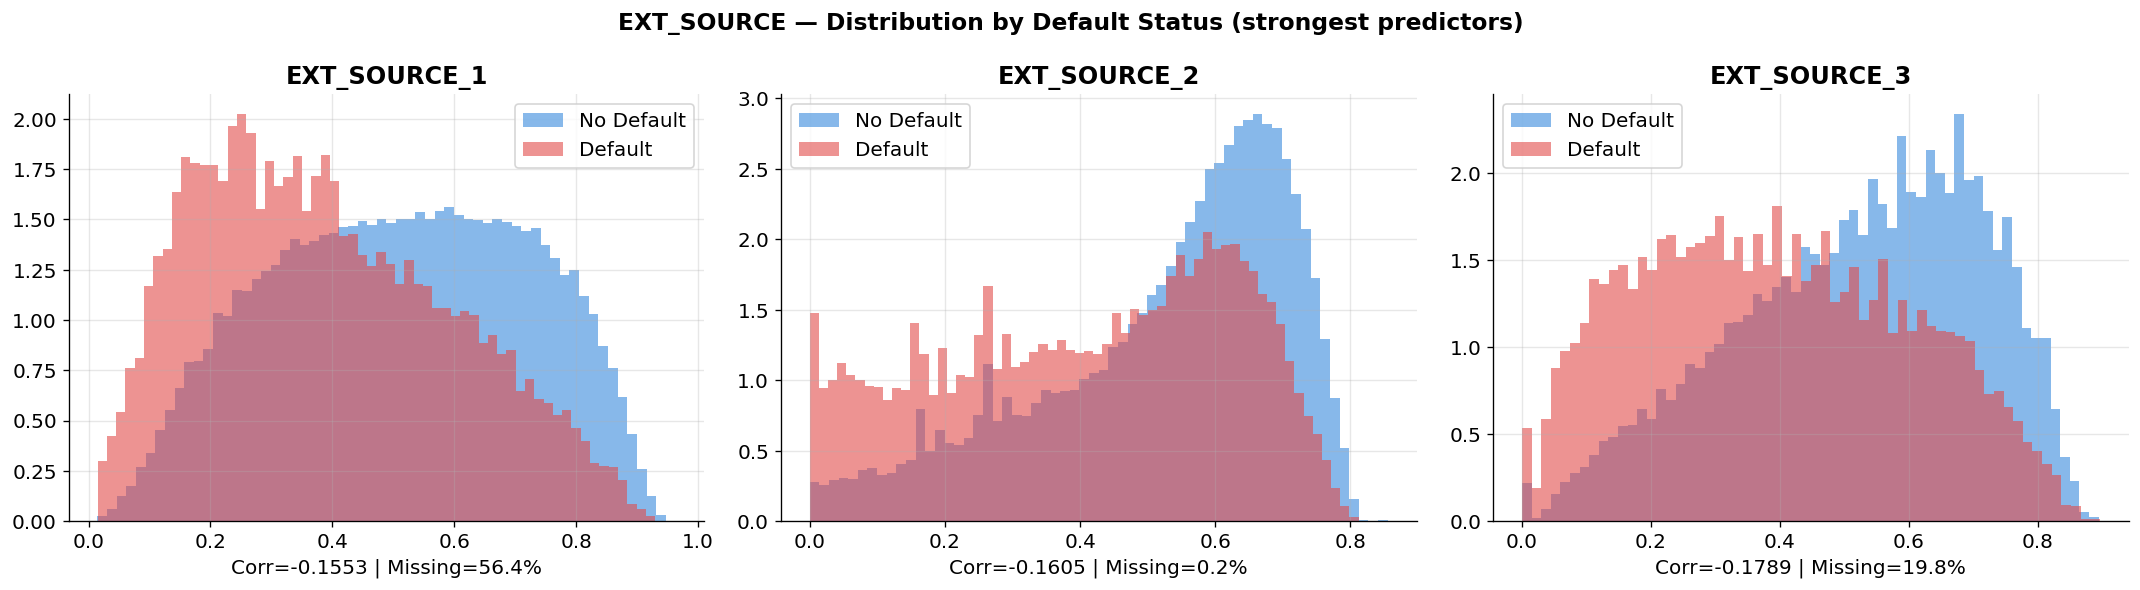

Saved: 06_ext_source/ext_source_distributions.png

EXT_SOURCE combination features — correlation with TARGET:
  EXT mean       : corr=-0.2221
  EXT min        : corr=-0.1853
  EXT max        : corr=-0.1969
  EXT1×EXT2      : corr=-0.1756
  EXT2×EXT3      : corr=-0.1995
  EXT1×EXT3      : corr=-0.1878


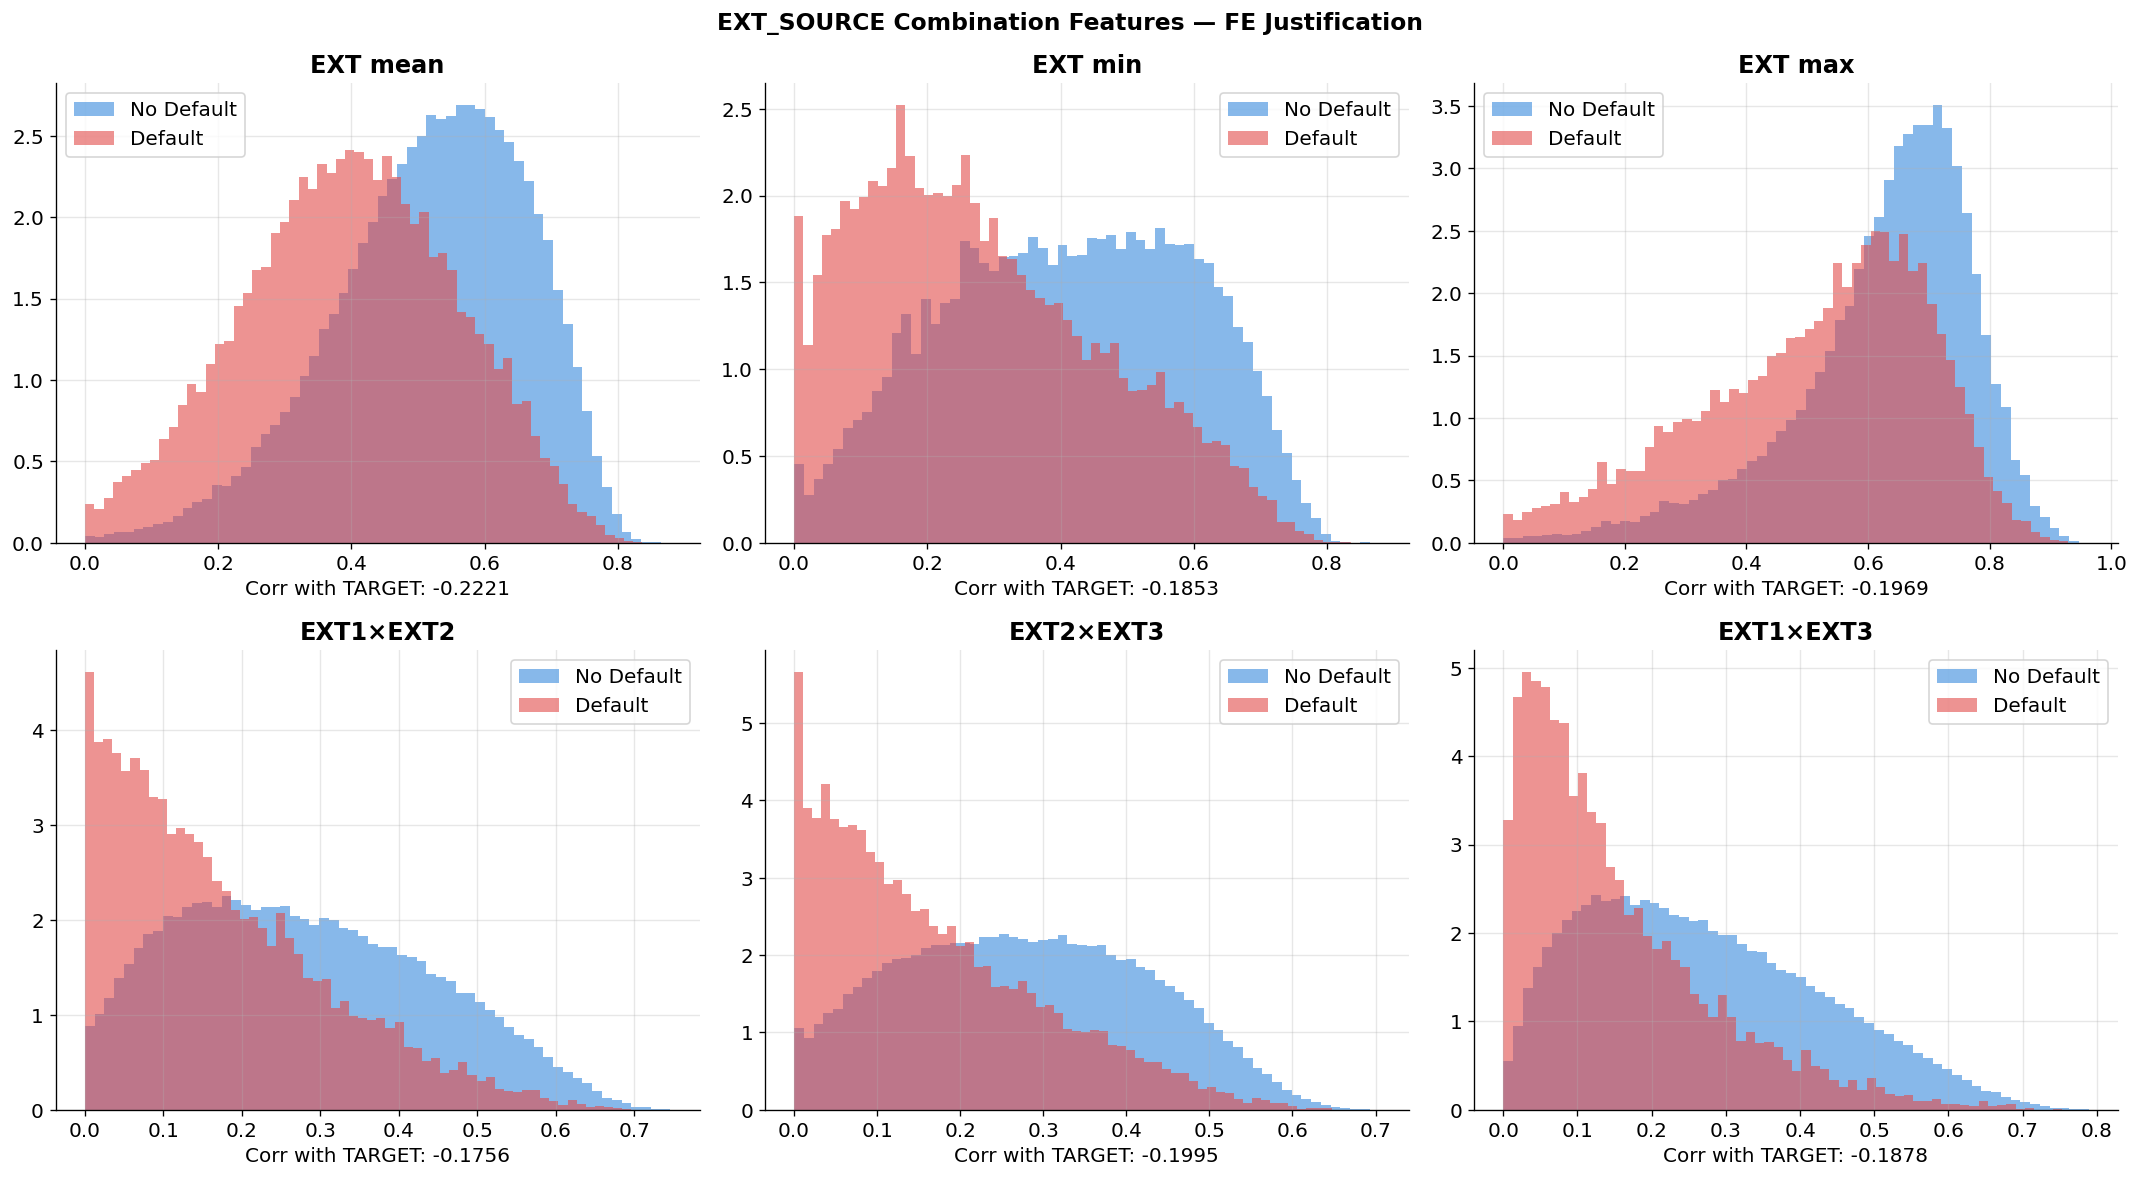

Saved: 06_ext_source/ext_source_combinations.png


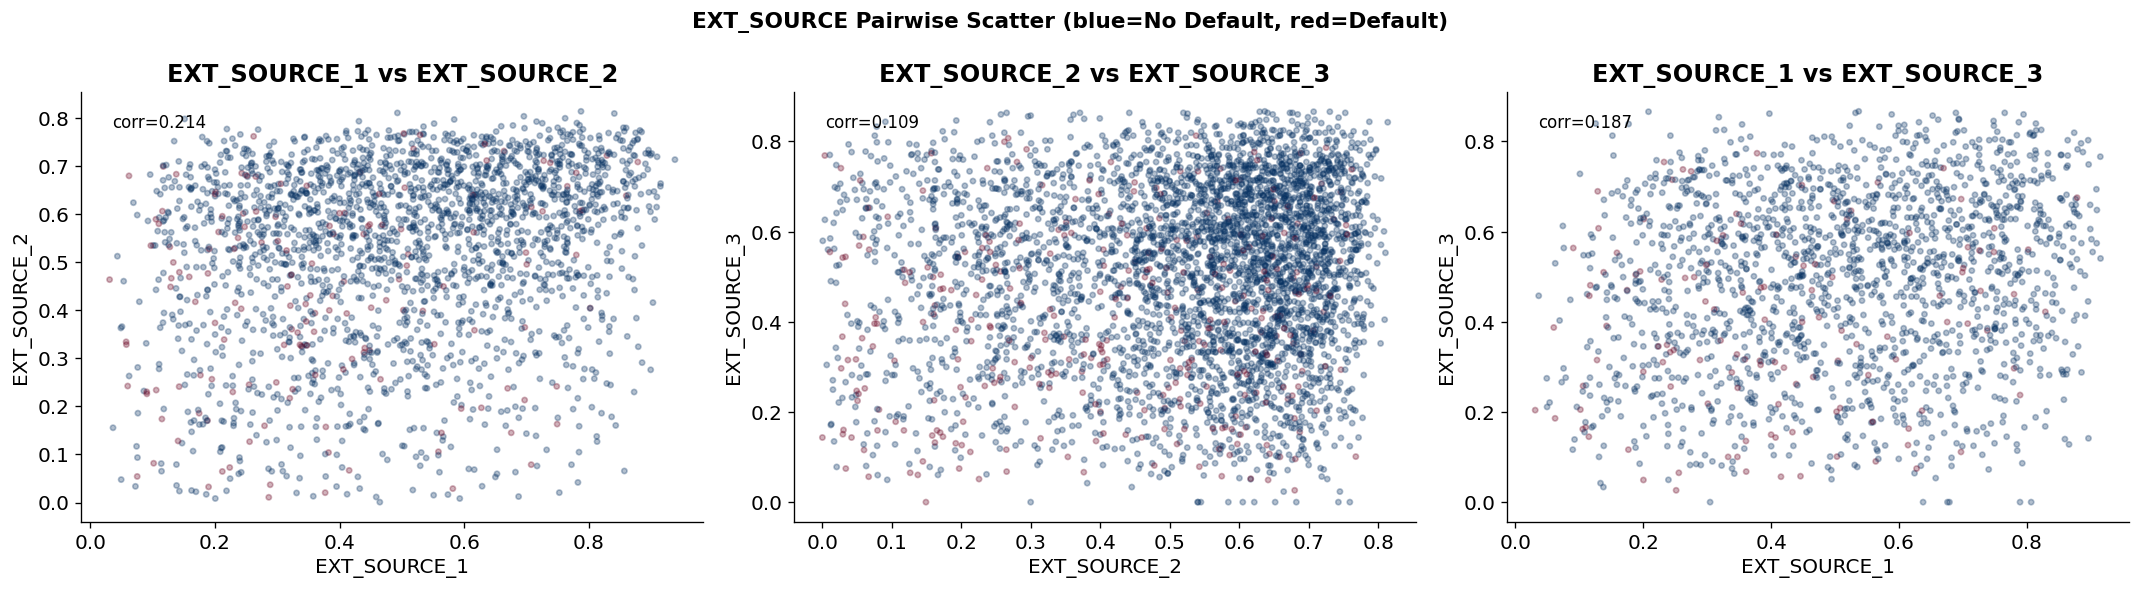

Saved: 06_ext_source/ext_source_pairwise.png


In [7]:
print('='*55)
print('EXT_SOURCE ANALYSIS — Primary Risk Signals')
print('='*55)

ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print('\nBasic statistics:')
print(df[ext_cols].describe().round(4))

print('\nCorrelation with TARGET:')
for col in ext_cols:
    corr = df[col].corr(df['TARGET'])
    miss = df[col].isnull().mean() * 100
    print(f'  {col}: corr={corr:.4f}  |  missing={miss:.2f}%')

print('\nMean values by TARGET:')
print(df.groupby('TARGET')[ext_cols].mean().round(4))

# ── Figure 1: EXT_SOURCE distributions ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(ext_cols):
    d0 = df[df['TARGET']==0][col].dropna()
    d1 = df[df['TARGET']==1][col].dropna()
    axes[idx].hist(d0, bins=60, alpha=0.6, label='No Default', color=PALETTE['ok'],      density=True)
    axes[idx].hist(d1, bins=60, alpha=0.6, label='Default',    color=PALETTE['default'], density=True)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    corr = df[col].corr(df['TARGET'])
    miss = df[col].isnull().mean() * 100
    axes[idx].set_xlabel(f'Corr={corr:.4f} | Missing={miss:.1f}%')

plt.suptitle('EXT_SOURCE — Distribution by Default Status (strongest predictors)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_ext_source' / 'ext_source_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_ext_source/ext_source_distributions.png')

# ── Figure 2: EXT_SOURCE combination features ─────────────────────────────────
df['_ext_mean']    = df[ext_cols].mean(axis=1)
df['_ext_min']     = df[ext_cols].min(axis=1)
df['_ext_max']     = df[ext_cols].max(axis=1)
df['_ext12_prod']  = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2']
df['_ext23_prod']  = df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
df['_ext13_prod']  = df['EXT_SOURCE_1'] * df['EXT_SOURCE_3']

combo_cols = ['_ext_mean', '_ext_min', '_ext_max', '_ext12_prod', '_ext23_prod', '_ext13_prod']
combo_labels = ['EXT mean', 'EXT min', 'EXT max', 'EXT1×EXT2', 'EXT2×EXT3', 'EXT1×EXT3']

print('\nEXT_SOURCE combination features — correlation with TARGET:')
for col, lbl in zip(combo_cols, combo_labels):
    corr = df[col].corr(df['TARGET'])
    print(f'  {lbl:<15}: corr={corr:.4f}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, (col, lbl) in enumerate(zip(combo_cols, combo_labels)):
    d0 = df[df['TARGET']==0][col].dropna()
    d1 = df[df['TARGET']==1][col].dropna()
    axes[idx].hist(d0, bins=60, alpha=0.6, label='No Default', color=PALETTE['ok'],      density=True)
    axes[idx].hist(d1, bins=60, alpha=0.6, label='Default',    color=PALETTE['default'], density=True)
    axes[idx].set_title(lbl, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    corr = df[col].corr(df['TARGET'])
    axes[idx].set_xlabel(f'Corr with TARGET: {corr:.4f}')

plt.suptitle('EXT_SOURCE Combination Features — FE Justification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_ext_source' / 'ext_source_combinations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_ext_source/ext_source_combinations.png')

# ── Figure 3: EXT_SOURCE pairwise scatter ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [('EXT_SOURCE_1','EXT_SOURCE_2'), ('EXT_SOURCE_2','EXT_SOURCE_3'), ('EXT_SOURCE_1','EXT_SOURCE_3')]
for idx, (c1, c2) in enumerate(pairs):
    sample = df.sample(min(5000, len(df)), random_state=42)
    axes[idx].scatter(sample[c1], sample[c2], c=sample['TARGET'],
                      cmap='RdBu_r', alpha=0.3, s=10)
    axes[idx].set_xlabel(c1)
    axes[idx].set_ylabel(c2)
    axes[idx].set_title(f'{c1} vs {c2}', fontweight='bold')
    corr = df[[c1, c2]].corr().iloc[0,1]
    axes[idx].text(0.05, 0.95, f'corr={corr:.3f}', transform=axes[idx].transAxes,
                  fontsize=10, verticalalignment='top')

plt.suptitle('EXT_SOURCE Pairwise Scatter (blue=No Default, red=Default)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_ext_source' / 'ext_source_pairwise.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_ext_source/ext_source_pairwise.png')


---
## 7. DAYS Features & Age Analysis

DAYS_BIRTH (age), DAYS_EMPLOYED, DAYS_REGISTRATION are negative values (days before application).  
DAYS_EMPLOYED = 365243 is a known anomaly (pensioner/unemployed flag) — 55,374 rows.


DAYS FEATURES — AGE & EMPLOYMENT ANALYSIS

Basic statistics (all values should be negative except anomaly):
       DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  \
count 307511.0000    307511.0000        307511.0000      307511.0000   
mean  -16037.0000     63815.0000         -4986.1000       -2994.2000   
std     4364.0000    141275.8000          3522.9000        1509.5000   
min   -25229.0000    -17912.0000        -24672.0000       -7197.0000   
25%   -19682.0000     -2760.0000         -7479.5000       -4299.0000   
50%   -15750.0000     -1213.0000         -4504.0000       -3254.0000   
75%   -12413.0000      -289.0000         -2010.0000       -1720.0000   
max    -7489.0000    365243.0000             0.0000           0.0000   

       DAYS_LAST_PHONE_CHANGE  
count             307510.0000  
mean                -962.9000  
std                  826.8000  
min                -4292.0000  
25%                -1570.0000  
50%                 -757.0000  
75%                

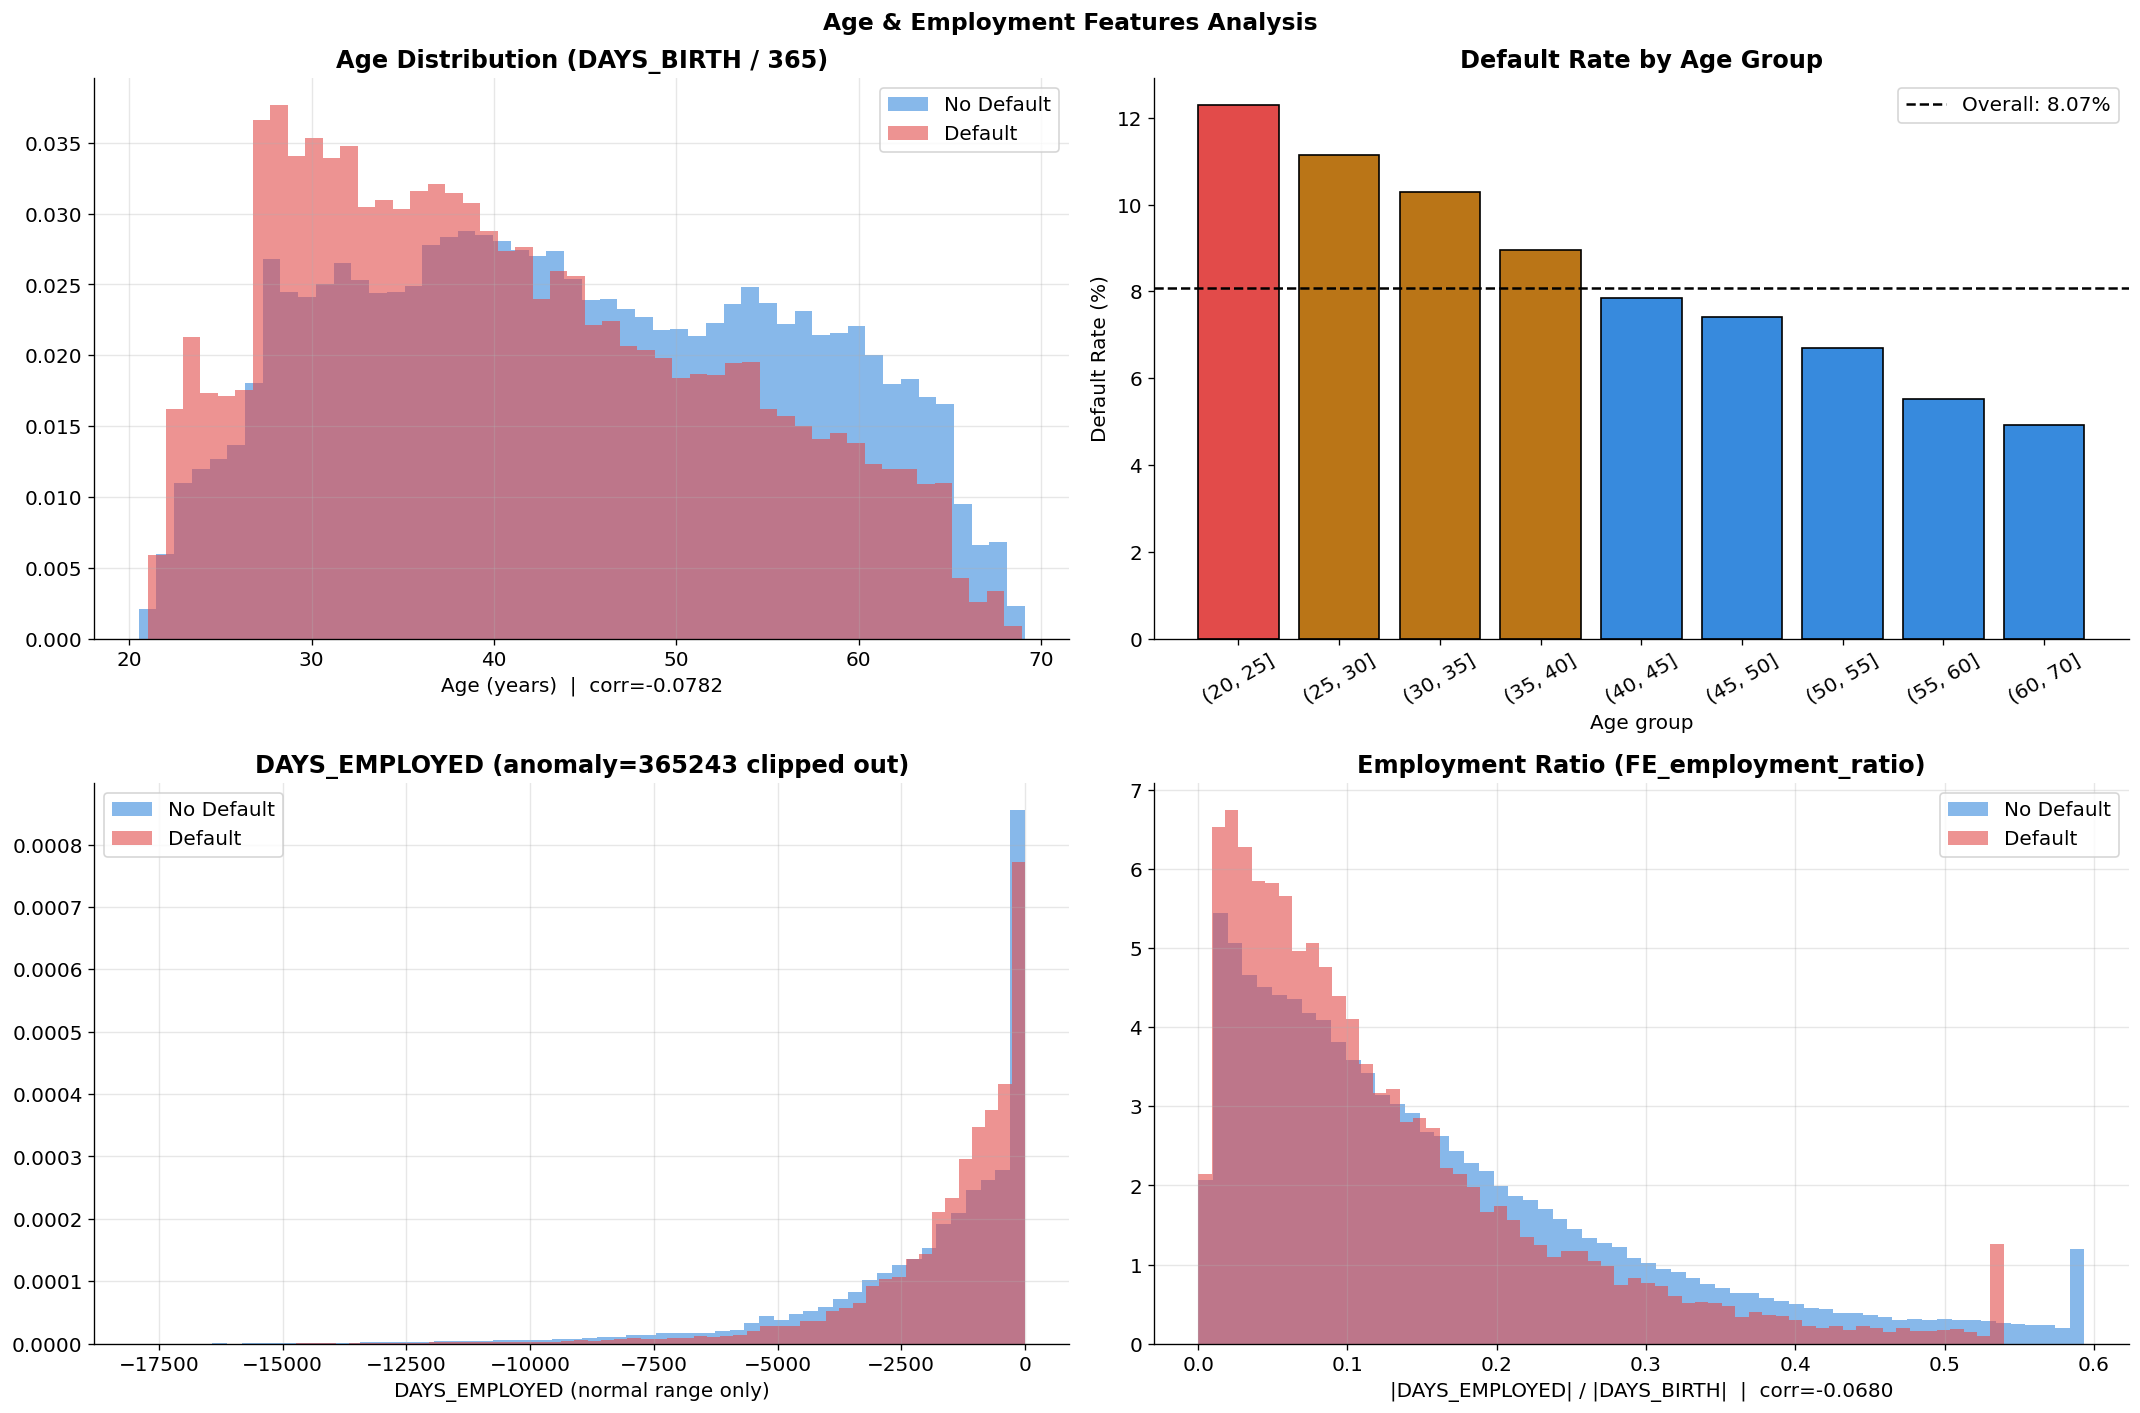

Saved: 07_days_features/age_employment_analysis.png


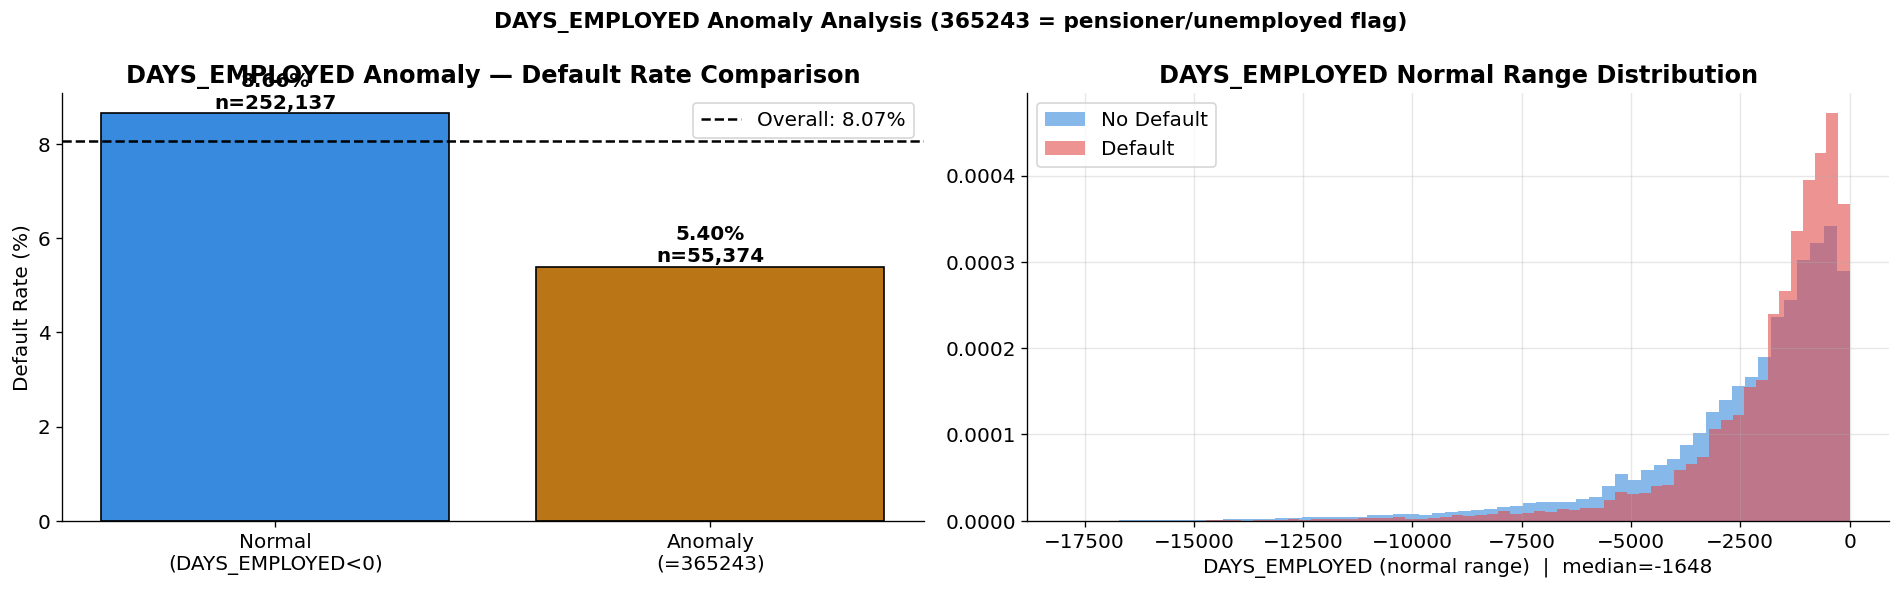

Saved: 07_days_features/days_employed_anomaly.png


In [8]:
print('='*55)
print('DAYS FEATURES — AGE & EMPLOYMENT ANALYSIS')
print('='*55)

days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']

print('\nBasic statistics (all values should be negative except anomaly):')
print(df[days_cols].describe().round(1))

print('\nCorrelation with TARGET:')
for col in days_cols:
    corr = df[col].corr(df['TARGET'])
    miss = df[col].isnull().mean() * 100
    print(f'  {col:<30} corr={corr:.4f}  missing={miss:.2f}%')

# ── DAYS_EMPLOYED anomaly ─────────────────────────────────────────────────────
ANOMALY_VAL = 365243
anom_mask   = df['DAYS_EMPLOYED'] == ANOMALY_VAL
normal_mask = ~anom_mask

print(f'\nDAYS_EMPLOYED anomaly ({ANOMALY_VAL}):')
print(f'  Count          : {anom_mask.sum():,} rows ({anom_mask.mean()*100:.2f}%)')
print(f'  Default rate (anomaly)  : {df.loc[anom_mask, "TARGET"].mean()*100:.2f}%')
print(f'  Default rate (normal)   : {df.loc[normal_mask, "TARGET"].mean()*100:.2f}%')
print(f'  Normal median           : {df.loc[normal_mask, "DAYS_EMPLOYED"].median():.0f}')
print(f'  Decision: replace {ANOMALY_VAL} with median={df.loc[normal_mask, "DAYS_EMPLOYED"].median():.0f} + add DAYS_EMPLOYED_ANOM flag')

# ── Age analysis ──────────────────────────────────────────────────────────────
df['_age_years'] = abs(df['DAYS_BIRTH']) / 365

print('\nAge statistics by TARGET:')
print(df.groupby('TARGET')['_age_years'].describe().round(2))

age_bins   = [20, 25, 30, 35, 40, 45, 50, 55, 60, 70]
df['_age_group'] = pd.cut(df['_age_years'], bins=age_bins)
age_stats = df.groupby('_age_group', observed=True)['TARGET'].agg(
    default_rate='mean', count='count'
).reset_index()
age_stats['default_rate'] = age_stats['default_rate'] * 100
print('\nDefault rate by age group:')
print(age_stats.to_string(index=False))

# ── Figure 1: Age & Days ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Age distribution
d0_age = df[df['TARGET']==0]['_age_years']
d1_age = df[df['TARGET']==1]['_age_years']
axes[0,0].hist(d0_age, bins=50, alpha=0.6, label='No Default', color=PALETTE['ok'],      density=True)
axes[0,0].hist(d1_age, bins=50, alpha=0.6, label='Default',    color=PALETTE['default'], density=True)
axes[0,0].set_title('Age Distribution (DAYS_BIRTH / 365)', fontweight='bold')
axes[0,0].set_xlabel(f'Age (years)  |  corr={df["_age_years"].corr(df["TARGET"]):.4f}')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Default rate by age group
ages_str = [str(x) for x in age_stats['_age_group']]
colors_age = [
    PALETTE['default']   if r > overall_dr * 1.5
    else PALETTE['highlight'] if r > overall_dr
    else PALETTE['ok']
    for r in age_stats['default_rate']
]
axes[0,1].bar(ages_str, age_stats['default_rate'], color=colors_age, edgecolor='black')
axes[0,1].axhline(overall_dr, color='black', ls='--', lw=1.5,
                  label=f'Overall: {overall_dr:.2f}%')
axes[0,1].set_xlabel('Age group')
axes[0,1].set_ylabel('Default Rate (%)')
axes[0,1].set_title('Default Rate by Age Group', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend()

# DAYS_EMPLOYED — with anomaly
axes[1,0].hist(df[df['TARGET']==0]['DAYS_EMPLOYED'].clip(upper=0), bins=60,
               alpha=0.6, label='No Default', color=PALETTE['ok'],      density=True)
axes[1,0].hist(df[df['TARGET']==1]['DAYS_EMPLOYED'].clip(upper=0), bins=60,
               alpha=0.6, label='Default',    color=PALETTE['default'], density=True)
axes[1,0].set_title('DAYS_EMPLOYED (anomaly=365243 clipped out)', fontweight='bold')
axes[1,0].set_xlabel('DAYS_EMPLOYED (normal range only)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Employment ratio
df['_emp_ratio'] = abs(df.loc[normal_mask, 'DAYS_EMPLOYED']) / (abs(df['DAYS_BIRTH']) + 1)
d0_emp = df[df['TARGET']==0]['_emp_ratio'].dropna()
d1_emp = df[df['TARGET']==1]['_emp_ratio'].dropna()
axes[1,1].hist(d0_emp.clip(upper=d0_emp.quantile(0.99)), bins=60, alpha=0.6,
               label='No Default', color=PALETTE['ok'],      density=True)
axes[1,1].hist(d1_emp.clip(upper=d1_emp.quantile(0.99)), bins=60, alpha=0.6,
               label='Default',    color=PALETTE['default'], density=True)
axes[1,1].set_title('Employment Ratio (FE_employment_ratio)', fontweight='bold')
axes[1,1].set_xlabel(f'|DAYS_EMPLOYED| / |DAYS_BIRTH|  |  corr={df["_emp_ratio"].corr(df["TARGET"]):.4f}')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Age & Employment Features Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_days_features' / 'age_employment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_days_features/age_employment_analysis.png')

# ── Figure 2: DAYS_EMPLOYED anomaly detail ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

anom_dr = df.loc[anom_mask,   'TARGET'].mean() * 100
norm_dr = df.loc[normal_mask, 'TARGET'].mean() * 100
axes[0].bar(['Normal\n(DAYS_EMPLOYED<0)', f'Anomaly\n(={ANOMALY_VAL})'],
            [norm_dr, anom_dr],
            color=[PALETTE['ok'], PALETTE['highlight']], edgecolor='black')
axes[0].axhline(overall_dr, color='black', ls='--', lw=1.5,
                label=f'Overall: {overall_dr:.2f}%')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('DAYS_EMPLOYED Anomaly — Default Rate Comparison', fontweight='bold')
axes[0].legend()
axes[0].text(0, norm_dr + 0.1, f'{norm_dr:.2f}%\nn={normal_mask.sum():,}', ha='center', fontweight='bold')
axes[0].text(1, anom_dr + 0.1, f'{anom_dr:.2f}%\nn={anom_mask.sum():,}',  ha='center', fontweight='bold')

axes[1].hist(df.loc[normal_mask & (df['TARGET']==0), 'DAYS_EMPLOYED'], bins=60,
             alpha=0.6, label='No Default', color=PALETTE['ok'],      density=True)
axes[1].hist(df.loc[normal_mask & (df['TARGET']==1), 'DAYS_EMPLOYED'], bins=60,
             alpha=0.6, label='Default',    color=PALETTE['default'], density=True)
axes[1].set_title('DAYS_EMPLOYED Normal Range Distribution', fontweight='bold')
axes[1].set_xlabel(f'DAYS_EMPLOYED (normal range)  |  median={df.loc[normal_mask, "DAYS_EMPLOYED"].median():.0f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DAYS_EMPLOYED Anomaly Analysis (365243 = pensioner/unemployed flag)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_days_features' / 'days_employed_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_days_features/days_employed_anomaly.png')


---
## 8. Numerical Features Analysis

FLAG columns, OWN_CAR_AGE, REGION_RATING, and remaining numerical columns.


NUMERICAL FEATURES — CORRELATION ANALYSIS

All numerical features: 104

Top 30 by |correlation| with TARGET:
EXT_SOURCE_3                  -0.1789
EXT_SOURCE_2                  -0.1605
EXT_SOURCE_1                  -0.1553
DAYS_BIRTH                     0.0782
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
FLAG_EMP_PHONE                 0.0460
DAYS_EMPLOYED                 -0.0449
REG_CITY_NOT_LIVE_CITY         0.0444
FLAG_DOCUMENT_3                0.0443
FLOORSMAX_AVG                 -0.0440
FLOORSMAX_MEDI                -0.0438
FLOORSMAX_MODE                -0.0432
DAYS_REGISTRATION              0.0420
AMT_GOODS_PRICE               -0.0396
OWN_CAR_AGE                    0.0376
REGION_POPULATION_RELATIVE    -0.0372
ELEVATORS_AVG                 -0.0342
ELEVATORS_MEDI                -0.0339
FLOORSMIN_AVG                 -0.0336
FLOORSMIN_MEDI   

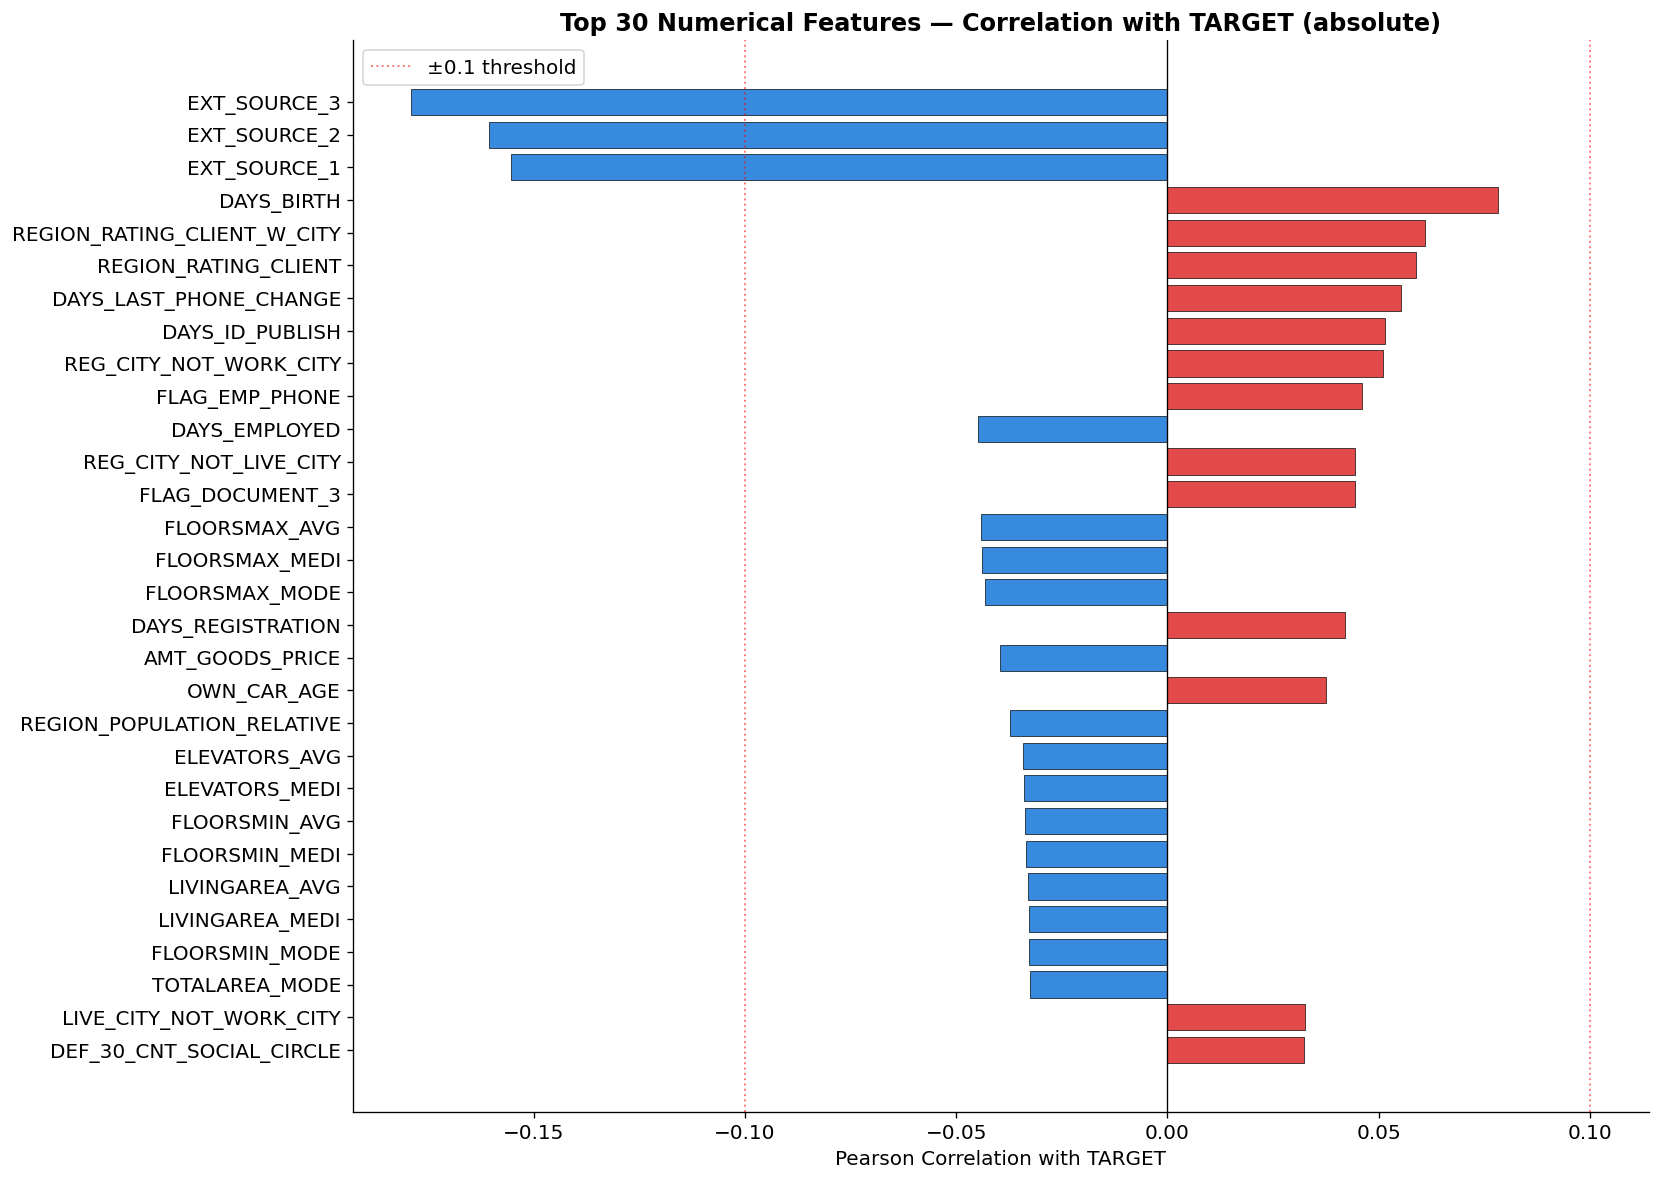

Saved: 05_numerical/numerical_correlations.png

FLAG columns — default rate when 0 vs 1:
             col  flag_0  flag_1   lift
 FLAG_DOCUMENT_2  8.0720 30.7690 3.8120
FLAG_DOCUMENT_21  8.0710 13.5920 1.6840
  FLAG_EMP_PHONE  5.4000  8.6600 1.6040
 FLAG_DOCUMENT_3  6.1830  8.8450 1.4310
 FLAG_WORK_PHONE  7.6850  9.6300 1.2530
FLAG_DOCUMENT_20  8.0730  8.3330 1.0320
FLAG_CONT_MOBILE  7.8400  8.0730 1.0300
 FLAG_DOCUMENT_5  8.0740  8.0030 0.9910
      FLAG_EMAIL  8.0850  7.8780 0.9740
 FLAG_DOCUMENT_8  8.1380  7.3370 0.9020
      FLAG_PHONE  8.4780  7.0360 0.8300
FLAG_DOCUMENT_19  8.0740  6.5570 0.8120
FLAG_DOCUMENT_11  8.0800  6.2340 0.7720
 FLAG_DOCUMENT_9  8.0800  6.1770 0.7640
FLAG_DOCUMENT_18  8.0920  5.6800 0.7020
 FLAG_DOCUMENT_6  8.3150  5.5650 0.6690
 FLAG_DOCUMENT_7  8.0730  5.0850 0.6300
FLAG_DOCUMENT_16  8.1050  4.9130 0.6060
FLAG_DOCUMENT_14  8.0870  3.3220 0.4110
FLAG_DOCUMENT_15  8.0790  2.9570 0.3660
FLAG_DOCUMENT_13  8.0920  2.7680 0.3420
FLAG_DOCUMENT_17  8.0740  2.439

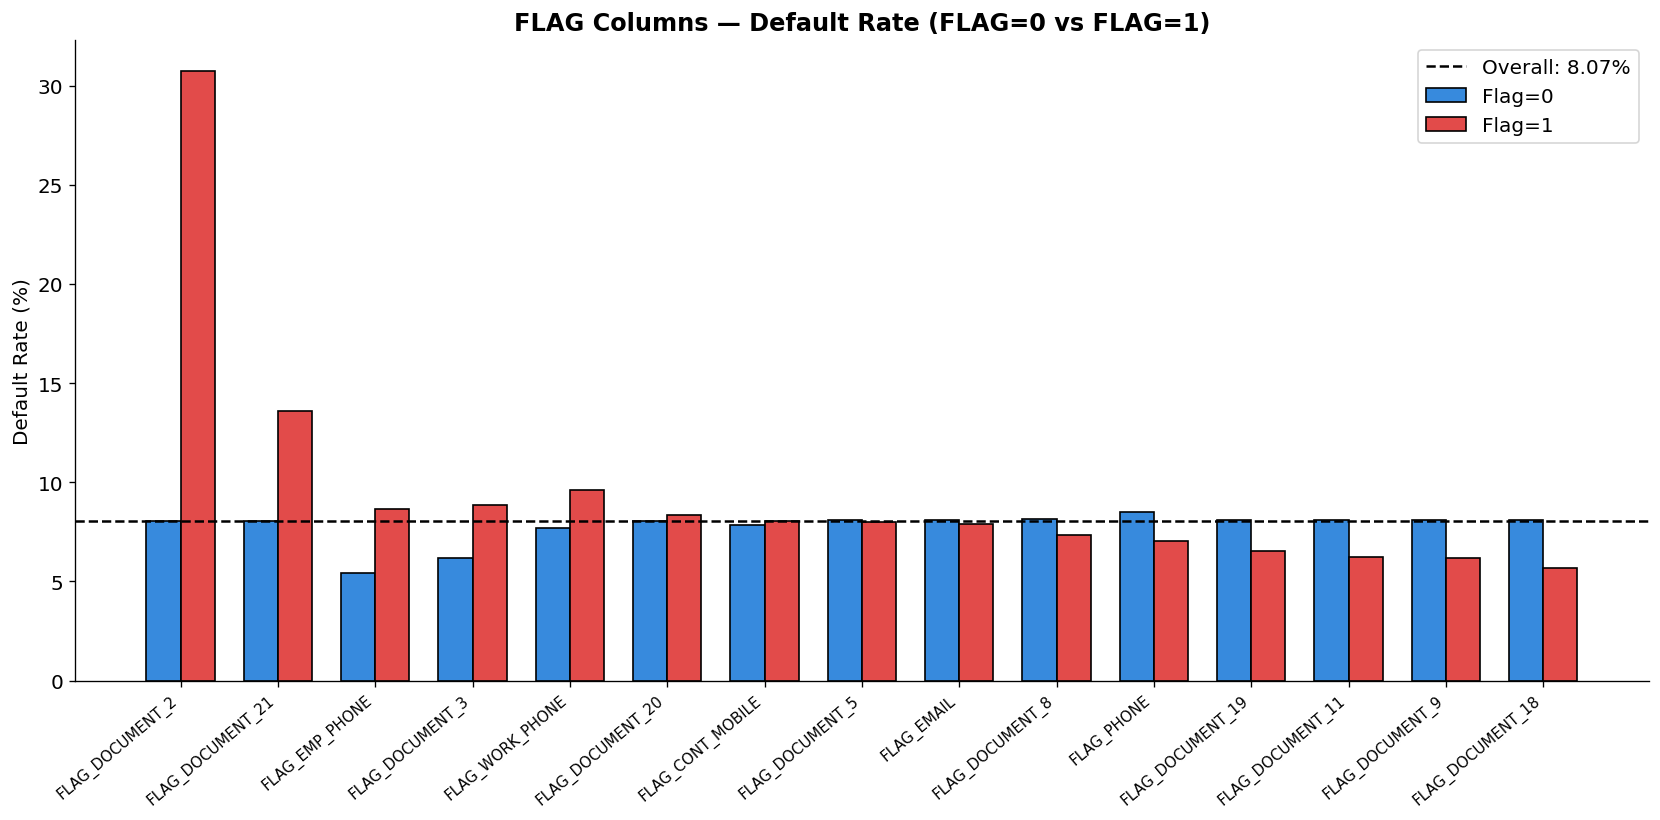

Saved: 05_numerical/flag_columns_default.png

Region columns: ['REGION_POPULATION_RELATIVE', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']

Region rating default rates:
 REGION_RATING_CLIENT  default_rate  count
                    1        4.8200  32197
                    2        7.8890 226984
                    3       11.1030  48330

OWN_CAR_AGE analysis:
  FLAG_OWN_CAR=Y count : 104,587
  OWN_CAR_AGE missing  : 66.0%
  Default rate (has car): 7.24%
  Default rate (no car) : 8.50%


In [9]:
print('='*55)
print('NUMERICAL FEATURES — CORRELATION ANALYSIS')
print('='*55)

# All numeric columns except IDs and target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['SK_ID_CURR', 'TARGET'] and not c.startswith('_')]

# Correlation with TARGET
corr_target = df[num_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)

print(f'\nAll numerical features: {len(num_cols)}')
print('\nTop 30 by |correlation| with TARGET:')
print(corr_target.head(30).round(4).to_string())

print('\nBottom 10 (weakest):')
print(corr_target.tail(10).round(4).to_string())

# ── Figure 1: Correlation bar chart ──────────────────────────────────────────
top30 = corr_target.head(30)
colors_corr = [PALETTE['default'] if v > 0 else PALETTE['ok'] for v in top30.values]

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(top30.index[::-1], top30.values[::-1],
        color=colors_corr[::-1], edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(0.1,  color='red',   ls=':', lw=1.2, alpha=0.5, label='±0.1 threshold')
ax.axvline(-0.1, color='red',   ls=':', lw=1.2, alpha=0.5)
ax.set_xlabel('Pearson Correlation with TARGET')
ax.set_title('Top 30 Numerical Features — Correlation with TARGET (absolute)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '05_numerical' / 'numerical_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_numerical/numerical_correlations.png')

# ── Figure 2: FLAG columns default rate ───────────────────────────────────────
flag_cols = [c for c in df.columns if c.startswith('FLAG_') and df[c].nunique() <= 2]
flag_stats = []
for col in flag_cols:
    dr0 = df[df[col]==0]['TARGET'].mean() * 100 if (df[col]==0).any() else 0
    dr1 = df[df[col]==1]['TARGET'].mean() * 100 if (df[col]==1).any() else 0
    flag_stats.append({'col': col, 'flag_0': dr0, 'flag_1': dr1, 'lift': dr1/dr0 if dr0>0 else 0})
flag_df = pd.DataFrame(flag_stats).sort_values('lift', ascending=False)

print('\nFLAG columns — default rate when 0 vs 1:')
print(flag_df.round(3).to_string(index=False))

top_flags = flag_df.head(15).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(top_flags))
w = 0.35
ax.bar(x - w/2, top_flags['flag_0'], w, color=PALETTE['ok'],      label='Flag=0', edgecolor='black')
ax.bar(x + w/2, top_flags['flag_1'], w, color=PALETTE['default'], label='Flag=1', edgecolor='black')
ax.axhline(overall_dr, color='black', ls='--', lw=1.5,
           label=f'Overall: {overall_dr:.2f}%')
ax.set_xticks(x)
ax.set_xticklabels(top_flags['col'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Default Rate (%)')
ax.set_title('FLAG Columns — Default Rate (FLAG=0 vs FLAG=1)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '05_numerical' / 'flag_columns_default.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_numerical/flag_columns_default.png')

# ── Figure 3: REGION RATING ───────────────────────────────────────────────────
region_cols = [c for c in df.columns if 'REGION_RATING' in c or 'REGION_POPULATION' in c]
print(f'\nRegion columns: {region_cols}')

if 'REGION_RATING_CLIENT' in df.columns:
    reg_stats = df.groupby('REGION_RATING_CLIENT')['TARGET'].agg(
        default_rate='mean', count='count'
    ).reset_index()
    reg_stats['default_rate'] = reg_stats['default_rate'] * 100
    print('\nRegion rating default rates:')
    print(reg_stats.round(3).to_string(index=False))

# OWN_CAR_AGE analysis
if 'OWN_CAR_AGE' in df.columns and 'FLAG_OWN_CAR' in df.columns:
    print('\nOWN_CAR_AGE analysis:')
    print(f'  FLAG_OWN_CAR=Y count : {(df["FLAG_OWN_CAR"]=="Y").sum():,}')
    print(f'  OWN_CAR_AGE missing  : {df["OWN_CAR_AGE"].isnull().mean()*100:.1f}%')
    dr_car    = df[df['FLAG_OWN_CAR']=='Y']['TARGET'].mean() * 100
    dr_nocar  = df[df['FLAG_OWN_CAR']=='N']['TARGET'].mean() * 100
    print(f'  Default rate (has car): {dr_car:.2f}%')
    print(f'  Default rate (no car) : {dr_nocar:.2f}%')


---
## 9. Supplementary Tables Analysis

Bureau, previous application, POS CASH, credit card, and installments — key aggregation signals.


SUPPLEMENTARY TABLES — AGGREGATION SIGNAL ANALYSIS

--- BUREAU ---
  Shape: (1716428, 17)
  Unique SK_ID_CURR: 305,811
  Coverage: 85.4% of train IDs in bureau
  Coverage inverse: 85.7% of applicants have bureau records

  CREDIT_ACTIVE values:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

  CREDIT_TYPE values:
CREDIT_TYPE
Consumer credit                           1251615
Credit card                                402195
Car loan                                    27690
Mortgage                                    18391
Microloan                                   12413
Loan for business development                1975
Another type of loan                         1017
Unknown type of loan                          555
Loan for working capital replenishment        469
Cash loan (non-earmarked)                      56
Name: count, dtype: int64

Bureau agg features — correlation with TARGET:
  bureau_count            

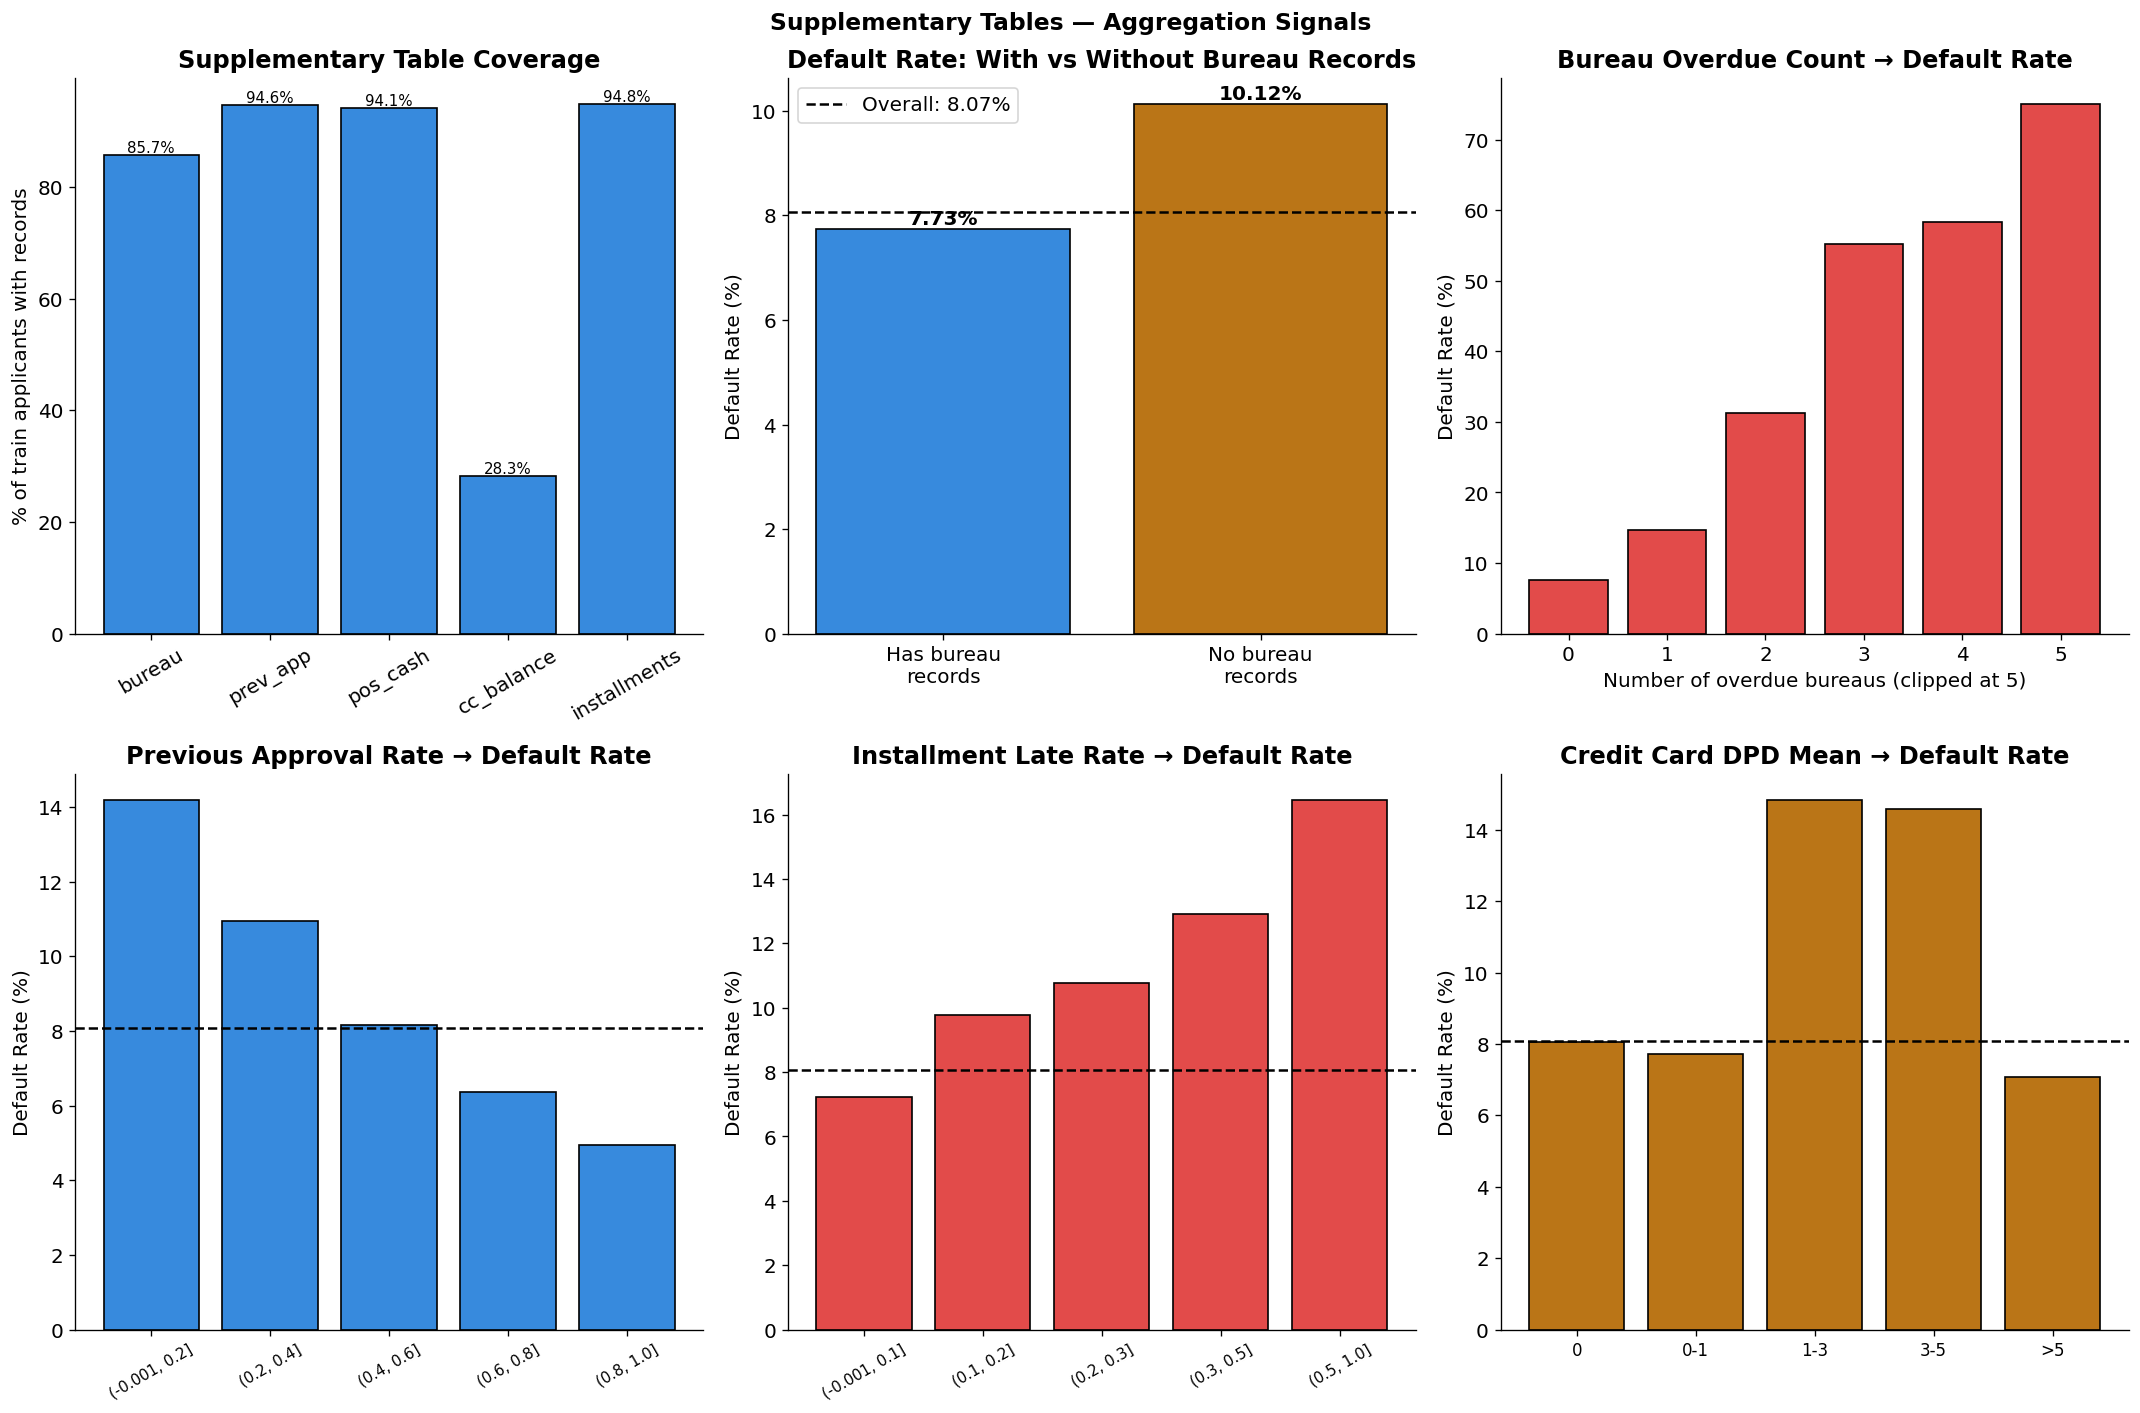

Saved: 08_supplementary/supplementary_signals.png


In [10]:
print('='*55)
print('SUPPLEMENTARY TABLES — AGGREGATION SIGNAL ANALYSIS')
print('='*55)

overall_dr = df['TARGET'].mean() * 100

# ── Bureau analysis ───────────────────────────────────────────────────────────
print('\n--- BUREAU ---')
print(f'  Shape: {bureau.shape}')
print(f'  Unique SK_ID_CURR: {bureau["SK_ID_CURR"].nunique():,}')
print(f'  Coverage: {bureau["SK_ID_CURR"].isin(df["SK_ID_CURR"]).mean()*100:.1f}% of train IDs in bureau')
print(f'  Coverage inverse: {df["SK_ID_CURR"].isin(bureau["SK_ID_CURR"]).mean()*100:.1f}% of applicants have bureau records')
print(f'\n  CREDIT_ACTIVE values:')
print(bureau['CREDIT_ACTIVE'].value_counts())
print(f'\n  CREDIT_TYPE values:')
print(bureau['CREDIT_TYPE'].value_counts().head(10))

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    bureau_count=('SK_ID_BUREAU', 'count'),
    bureau_active=('CREDIT_ACTIVE', lambda x: (x=='Active').sum()),
    bureau_overdue=('AMT_CREDIT_SUM_OVERDUE', lambda x: (x > 0).sum()),
    bureau_credit_sum=('AMT_CREDIT_SUM', 'sum'),
    bureau_debt_sum=('AMT_CREDIT_SUM_DEBT', 'sum'),
).reset_index()

bureau_merged = df[['SK_ID_CURR', 'TARGET']].merge(bureau_agg, on='SK_ID_CURR', how='left')
print('\nBureau agg features — correlation with TARGET:')
for col in ['bureau_count', 'bureau_active', 'bureau_overdue', 'bureau_credit_sum', 'bureau_debt_sum']:
    corr = bureau_merged[col].corr(bureau_merged['TARGET'])
    print(f'  {col:<25}: {corr:.4f}')

# ── Bureau balance DPD ────────────────────────────────────────────────────────
print('\n--- BUREAU BALANCE ---')
print(f'  Shape: {bureau_bal.shape}')
print('  STATUS values (DPD indicator):')
print(bureau_bal['STATUS'].value_counts())
print('  Note: 1-5 = overdue days buckets, C = closed, X = unknown, 0 = no DPD')

# ── Previous application ──────────────────────────────────────────────────────
print('\n--- PREVIOUS APPLICATION ---')
print(f'  Shape: {prev_app.shape}')
print(f'  Avg applications per client: {len(prev_app)/prev_app["SK_ID_CURR"].nunique():.1f}')
print('\n  NAME_CONTRACT_STATUS:')
print(prev_app['NAME_CONTRACT_STATUS'].value_counts())

prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    prev_count=('SK_ID_PREV', 'count'),
    prev_approved=('NAME_CONTRACT_STATUS', lambda x: (x=='Approved').sum()),
    prev_refused=('NAME_CONTRACT_STATUS', lambda x: (x=='Refused').sum()),
).reset_index()
prev_agg['prev_approved_rate'] = prev_agg['prev_approved'] / (prev_agg['prev_count'] + 1)

prev_merged = df[['SK_ID_CURR', 'TARGET']].merge(prev_agg, on='SK_ID_CURR', how='left')
print('\nPrevious app agg — correlation with TARGET:')
for col in ['prev_count', 'prev_approved', 'prev_refused', 'prev_approved_rate']:
    corr = prev_merged[col].corr(prev_merged['TARGET'])
    print(f'  {col:<25}: {corr:.4f}')

# ── Installments DPD ──────────────────────────────────────────────────────────
print('\n--- INSTALLMENTS ---')
print(f'  Shape: {installments.shape}')
installments['days_late'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['is_late']   = (installments['days_late'] > 0).astype(int)
inst_agg = installments.groupby('SK_ID_CURR').agg(
    inst_count=('SK_ID_PREV', 'count'),
    inst_late_rate=('is_late', 'mean'),
    inst_days_late_mean=('days_late', 'mean'),
    inst_payment_diff_mean=('AMT_INSTALMENT', lambda x: (installments.loc[x.index, 'AMT_INSTALMENT'] - installments.loc[x.index, 'AMT_PAYMENT']).mean()),
).reset_index()

inst_merged = df[['SK_ID_CURR', 'TARGET']].merge(inst_agg, on='SK_ID_CURR', how='left')
print('Installments agg — correlation with TARGET:')
for col in ['inst_count', 'inst_late_rate', 'inst_days_late_mean']:
    corr = inst_merged[col].corr(inst_merged['TARGET'])
    print(f'  {col:<30}: {corr:.4f}')

# ── Credit card ───────────────────────────────────────────────────────────────
print('\n--- CREDIT CARD BALANCE ---')
print(f'  Shape: {cc_bal.shape}')
cc_agg = cc_bal.groupby('SK_ID_CURR').agg(
    cc_count=('SK_ID_PREV', 'count'),
    cc_dpd_mean=('SK_DPD', 'mean'),
    cc_balance_mean=('AMT_BALANCE', 'mean'),
    cc_limit_mean=('AMT_CREDIT_LIMIT_ACTUAL', 'mean'),
).reset_index()
cc_agg['cc_utilization'] = cc_agg['cc_balance_mean'] / (cc_agg['cc_limit_mean'] + 1)

cc_merged = df[['SK_ID_CURR', 'TARGET']].merge(cc_agg, on='SK_ID_CURR', how='left')
print('Credit card agg — correlation with TARGET:')
for col in ['cc_count', 'cc_dpd_mean', 'cc_balance_mean', 'cc_utilization']:
    corr = cc_merged[col].corr(cc_merged['TARGET'])
    print(f'  {col:<25}: {corr:.4f}')

# ── Figure: Supplementary table coverage & signal ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Coverage
tables_info = {
    'bureau'      : bureau,
    'prev_app'    : prev_app,
    'pos_cash'    : pos_cash,
    'cc_balance'  : cc_bal,
    'installments': installments,
}
coverages  = [t['SK_ID_CURR'].isin(df['SK_ID_CURR']).mean()*100 for t in tables_info.values()]
app_covers = [df['SK_ID_CURR'].isin(t['SK_ID_CURR']).mean()*100 for t in tables_info.values()]
axes[0,0].bar(list(tables_info.keys()), app_covers, color=PALETTE['ok'], edgecolor='black')
axes[0,0].set_ylabel('% of train applicants with records')
axes[0,0].set_title('Supplementary Table Coverage', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(app_covers):
    axes[0,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

# Bureau active credit count
bureau_merged['has_bureau'] = bureau_merged['bureau_count'].notna().astype(int)
has_dr  = bureau_merged[bureau_merged['has_bureau']==1]['TARGET'].mean() * 100
none_dr = bureau_merged[bureau_merged['has_bureau']==0]['TARGET'].mean() * 100
axes[0,1].bar(['Has bureau\nrecords', 'No bureau\nrecords'], [has_dr, none_dr],
              color=[PALETTE['ok'], PALETTE['highlight']], edgecolor='black')
axes[0,1].axhline(overall_dr, color='black', ls='--', lw=1.5, label=f'Overall: {overall_dr:.2f}%')
axes[0,1].set_ylabel('Default Rate (%)')
axes[0,1].set_title('Default Rate: With vs Without Bureau Records', fontweight='bold')
axes[0,1].legend()
axes[0,1].text(0, has_dr+0.1,  f'{has_dr:.2f}%',  ha='center', fontweight='bold')
axes[0,1].text(1, none_dr+0.1, f'{none_dr:.2f}%', ha='center', fontweight='bold')

# Overdue count distribution
bureau_merged['bureau_overdue_clipped'] = bureau_merged['bureau_overdue'].clip(upper=5)
overdue_dr = bureau_merged.groupby('bureau_overdue_clipped')['TARGET'].mean() * 100
axes[0,2].bar(overdue_dr.index, overdue_dr.values, color=PALETTE['default'], edgecolor='black')
axes[0,2].set_xlabel('Number of overdue bureaus (clipped at 5)')
axes[0,2].set_ylabel('Default Rate (%)')
axes[0,2].set_title('Bureau Overdue Count → Default Rate', fontweight='bold')

# Previous approval rate vs default
prev_merged['approved_rate_bin'] = pd.cut(prev_merged['prev_approved_rate'],
                                          bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], include_lowest=True)
apr_dr = prev_merged.groupby('approved_rate_bin', observed=True)['TARGET'].mean() * 100
axes[1,0].bar(range(len(apr_dr)), apr_dr.values, color=PALETTE['ok'], edgecolor='black')
axes[1,0].set_xticks(range(len(apr_dr)))
axes[1,0].set_xticklabels([str(x) for x in apr_dr.index], rotation=30, fontsize=9)
axes[1,0].set_ylabel('Default Rate (%)')
axes[1,0].set_title('Previous Approval Rate → Default Rate', fontweight='bold')
axes[1,0].axhline(overall_dr, color='black', ls='--', lw=1.5)

# Installment late rate vs default
inst_merged['late_bin'] = pd.cut(inst_merged['inst_late_rate'],
                                  bins=[0, 0.1, 0.2, 0.3, 0.5, 1.0], include_lowest=True)
late_dr = inst_merged.groupby('late_bin', observed=True)['TARGET'].mean() * 100
axes[1,1].bar(range(len(late_dr)), late_dr.values, color=PALETTE['default'], edgecolor='black')
axes[1,1].set_xticks(range(len(late_dr)))
axes[1,1].set_xticklabels([str(x) for x in late_dr.index], rotation=30, fontsize=9)
axes[1,1].set_ylabel('Default Rate (%)')
axes[1,1].set_title('Installment Late Rate → Default Rate', fontweight='bold')
axes[1,1].axhline(overall_dr, color='black', ls='--', lw=1.5)

# CC DPD vs default
cc_merged['dpd_bin'] = pd.cut(cc_merged['cc_dpd_mean'].fillna(0),
                               bins=[-0.1, 0, 1, 3, 5, 100], labels=['0','0-1','1-3','3-5','>5'])
dpd_dr = cc_merged.groupby('dpd_bin', observed=True)['TARGET'].mean() * 100
axes[1,2].bar(range(len(dpd_dr)), dpd_dr.values, color=PALETTE['highlight'], edgecolor='black')
axes[1,2].set_xticks(range(len(dpd_dr)))
axes[1,2].set_xticklabels(dpd_dr.index.tolist(), fontsize=10)
axes[1,2].set_ylabel('Default Rate (%)')
axes[1,2].set_title('Credit Card DPD Mean → Default Rate', fontweight='bold')
axes[1,2].axhline(overall_dr, color='black', ls='--', lw=1.5)

plt.suptitle('Supplementary Tables — Aggregation Signals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_supplementary' / 'supplementary_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_supplementary/supplementary_signals.png')


---
## 10. Correlation Heatmap & High-Correlation Analysis

Identifying highly correlated feature pairs for the correlation filter (threshold=0.95).


CORRELATION ANALYSIS

Feature pairs with |corr| > 0.90: 10
Feature pairs with |corr| > 0.95: 10

Top 30 highly correlated pairs:
                    feature1                     feature2   corr
              FLAG_EMP_PHONE                DAYS_EMPLOYED 0.9998
    OBS_60_CNT_SOCIAL_CIRCLE     OBS_30_CNT_SOCIAL_CIRCLE 0.9985
              FLOORSMAX_MEDI                FLOORSMAX_AVG 0.9970
YEARS_BEGINEXPLUATATION_MEDI  YEARS_BEGINEXPLUATATION_AVG 0.9938
              FLOORSMAX_MEDI               FLOORSMAX_MODE 0.9882
             AMT_GOODS_PRICE                   AMT_CREDIT 0.9870
              FLOORSMAX_MODE                FLOORSMAX_AVG 0.9857
YEARS_BEGINEXPLUATATION_MODE  YEARS_BEGINEXPLUATATION_AVG 0.9719
YEARS_BEGINEXPLUATATION_MEDI YEARS_BEGINEXPLUATATION_MODE 0.9635
 REGION_RATING_CLIENT_W_CITY         REGION_RATING_CLIENT 0.9508

Building feature groups (AVG/MODE/MEDI): 7 columns
These are the primary source of high correlation — correlation filter will drop ~30 columns


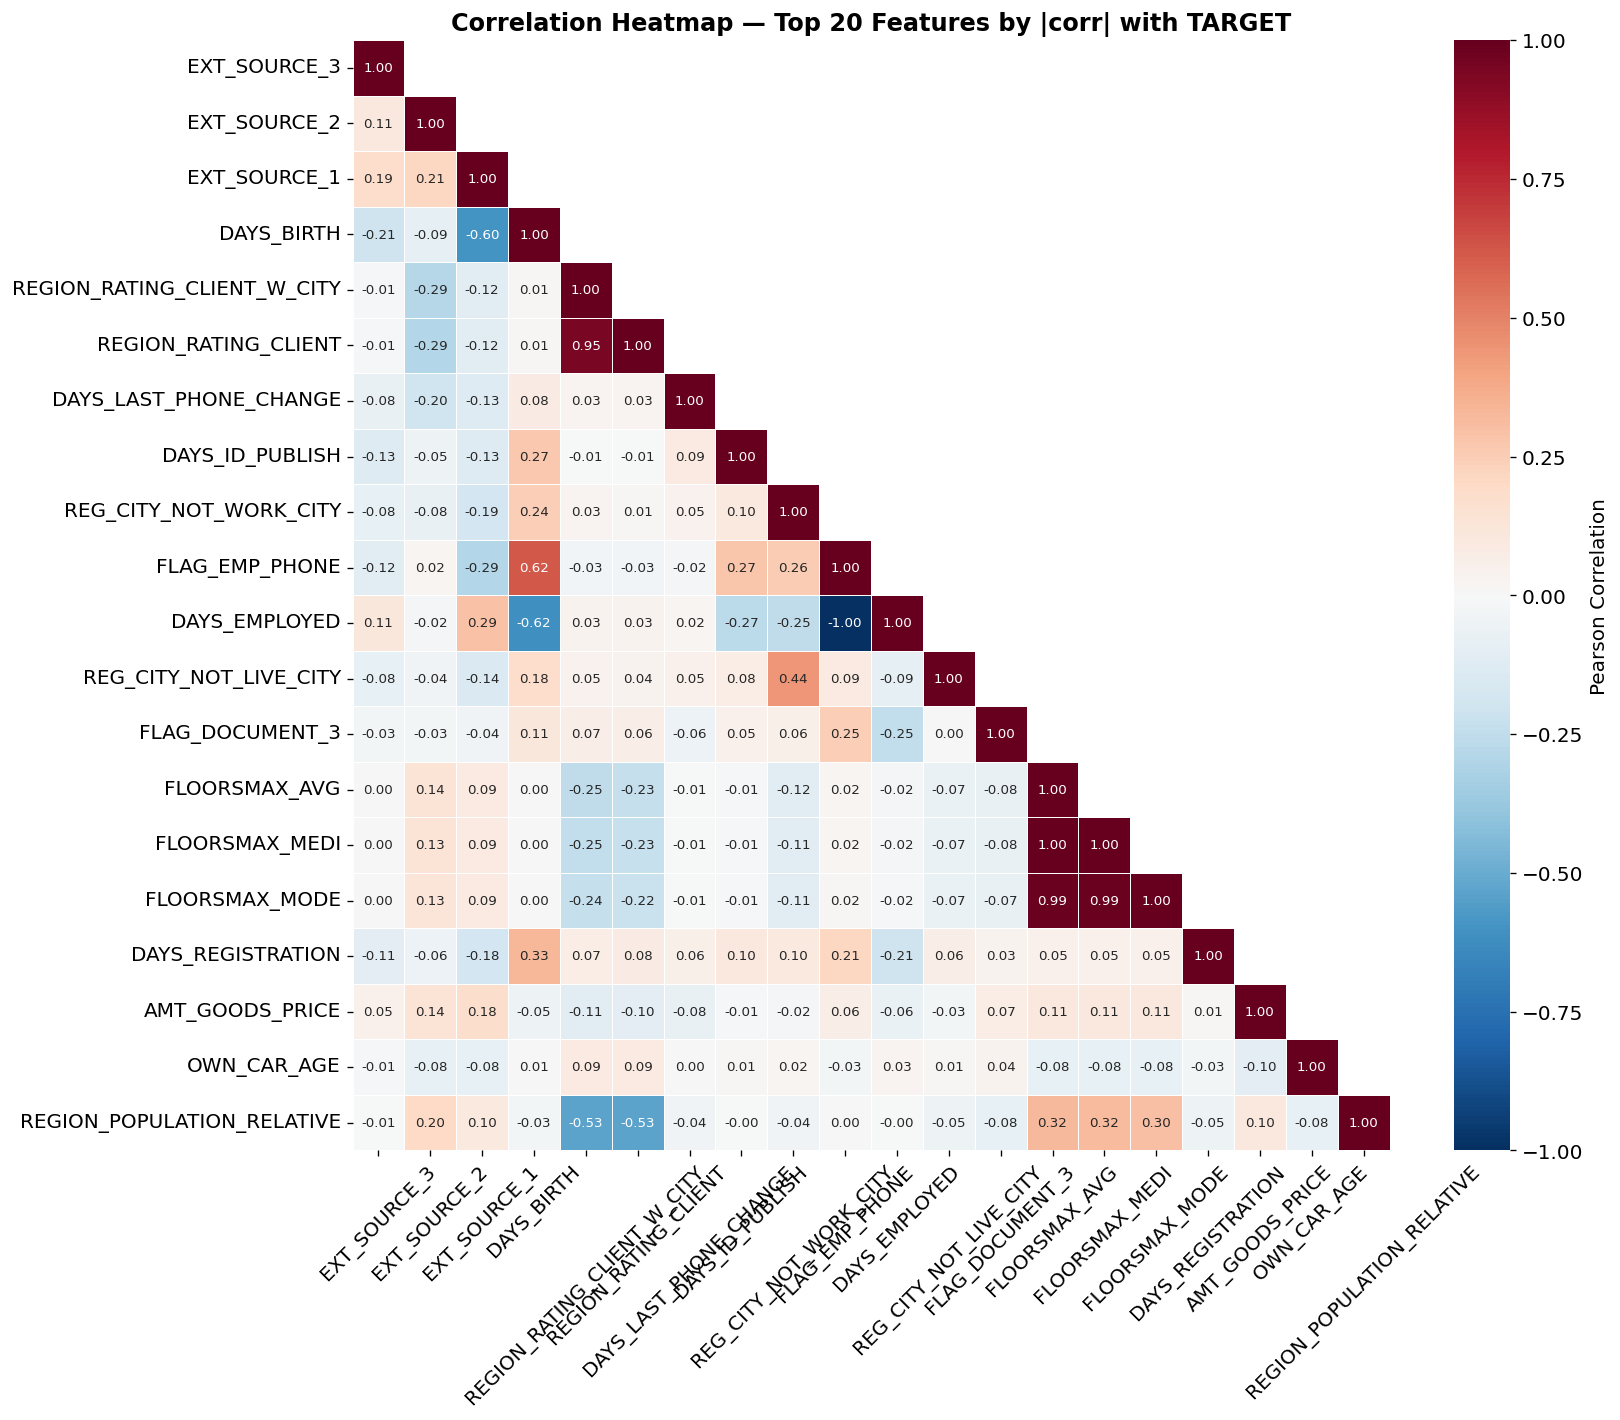

Saved: 09_correlations/top_features_heatmap.png


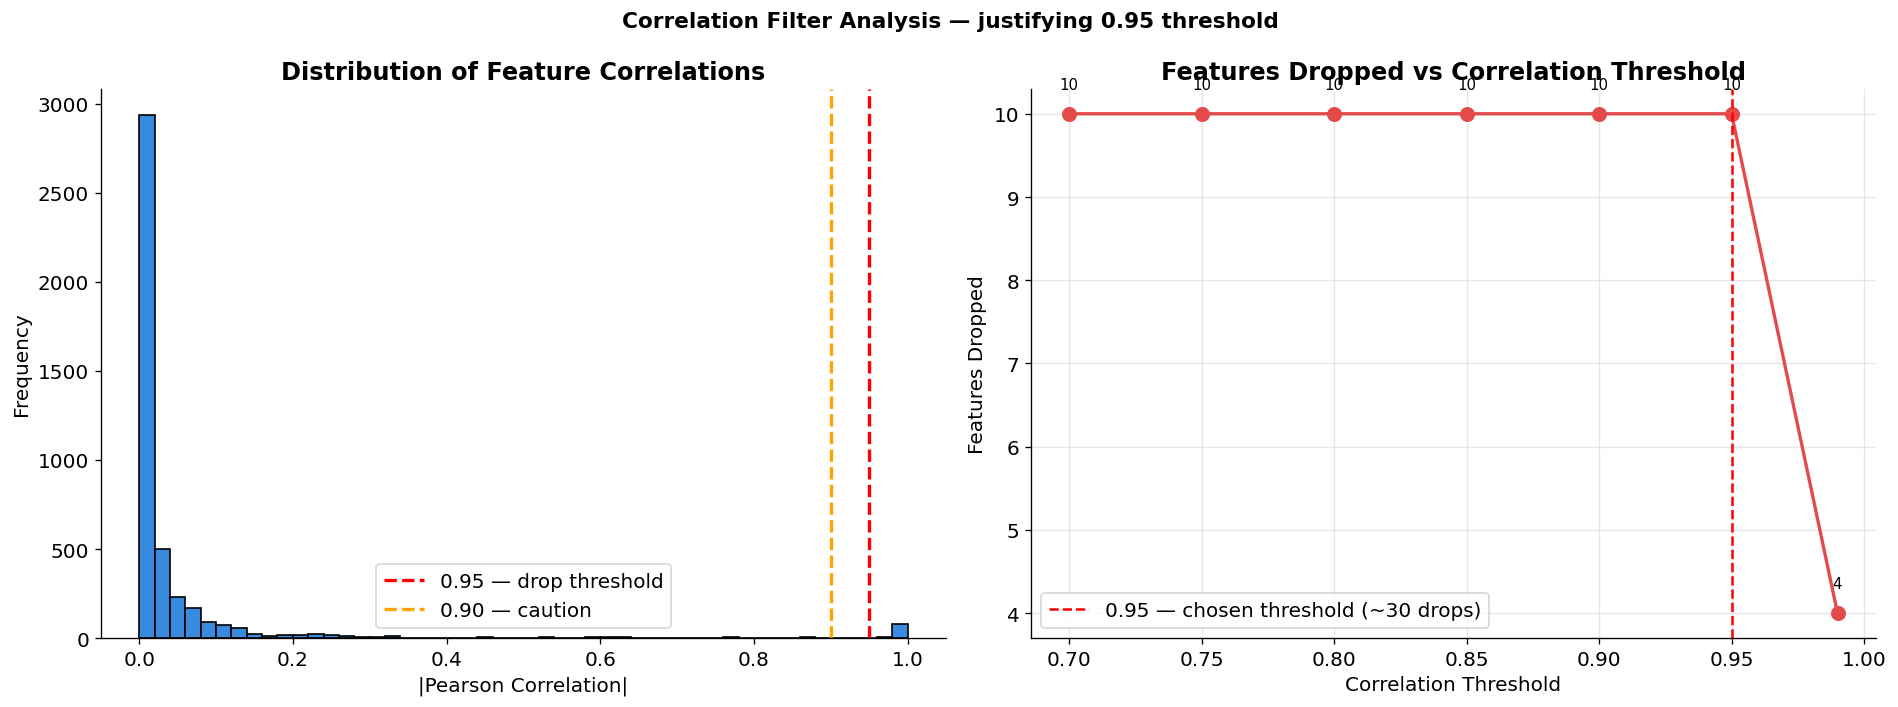

Saved: 09_correlations/correlation_filter_analysis.png


In [11]:
print('='*55)
print('CORRELATION ANALYSIS')
print('='*55)

num_cols_clean = [c for c in df.select_dtypes(include=[np.number]).columns
                  if c not in ['SK_ID_CURR', 'TARGET'] and not c.startswith('_')
                  and df[c].isnull().mean() < 0.5]

corr_matrix = df[num_cols_clean].corr().abs()

# High correlation pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.90
]
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['feature1', 'feature2', 'corr'])
high_corr_df = high_corr_df.sort_values('corr', ascending=False).reset_index(drop=True)

print(f'\nFeature pairs with |corr| > 0.90: {len(high_corr_df)}')
print(f'Feature pairs with |corr| > 0.95: {(high_corr_df["corr"] > 0.95).sum()}')
print('\nTop 30 highly correlated pairs:')
print(high_corr_df.head(30).round(4).to_string(index=False))

# Building features are the main correlated group
building_cols = [c for c in num_cols_clean if any(s in c for s in ['AVG', 'MODE', 'MEDI'])]
print(f'\nBuilding feature groups (AVG/MODE/MEDI): {len(building_cols)} columns')
print('These are the primary source of high correlation — correlation filter will drop ~30 columns')

# ── Figure 1: Correlation heatmap (top correlated features) ──────────────────
top_corr_features = corr_target.head(20).index.tolist()
corr_sub = df[top_corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_sub, dtype=bool), k=1)
sns.heatmap(
    corr_sub, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, ax=ax,
    annot_kws={'size': 8}, linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'}
)
ax.set_title('Correlation Heatmap — Top 20 Features by |corr| with TARGET', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / '09_correlations' / 'top_features_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_correlations/top_features_heatmap.png')

# ── Figure 2: High correlation pairs distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(corr_matrix.values.flatten(), bins=50,
             color=PALETTE['ok'], edgecolor='black')
axes[0].axvline(0.95, color='red',    ls='--', lw=2, label='0.95 — drop threshold')
axes[0].axvline(0.90, color='orange', ls='--', lw=2, label='0.90 — caution')
axes[0].set_xlabel('|Pearson Correlation|')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Feature Correlations', fontweight='bold')
axes[0].legend()

thresholds = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
drop_counts = [(high_corr_df['corr'] > t).sum() for t in thresholds]
axes[1].plot(thresholds, drop_counts, marker='o', color=PALETTE['default'], lw=2, markersize=8)
axes[1].axvline(0.95, color='red', ls='--', lw=1.5, label='0.95 — chosen threshold (~30 drops)')
axes[1].set_xlabel('Correlation Threshold')
axes[1].set_ylabel('Features Dropped')
axes[1].set_title('Features Dropped vs Correlation Threshold', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
for t, n in zip(thresholds, drop_counts):
    axes[1].text(t, n + 0.3, str(n), ha='center', fontsize=9)

plt.suptitle('Correlation Filter Analysis — justifying 0.95 threshold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_correlations' / 'correlation_filter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_correlations/correlation_filter_analysis.png')


---
## 11. EDA Conclusions & Pipeline Constants

All constants below are data-driven from this EDA and used consistently throughout preprocessing, feature engineering, and modeling.


FINRISKGUARD — EDA CONCLUSIONS
Home Credit Default Risk Dataset

[1] DATASET SUMMARY
  Train transactions : 307,511
  Train features     : 122
  Default rate       : 8.07% (24,825 default / 282,686 no default)
  Imbalance ratio    : 11.4:1
  Test transactions  : 48,744
  Supplementary rows : ~58M total across 6 tables

[2] MISSING VALUES
  Columns with missing   : 67 / 122
  DROP threshold         : >67% → 13 columns removed
  NaN flag columns       : 7 columns (missingness = signal)
  ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'OWN_CAR_AGE', 'DAYS_LAST_PHONE_CHANGE']

[3] CLASS IMBALANCE STRATEGY
  XGBoost  → scale_pos_weight = 11
  LightGBM → is_unbalance = True
  CatBoost → auto_class_weights = 'Balanced'

[4] DAYS_EMPLOYED ANOMALY
  Value=365243 → 55,374 rows (18.0%)
  Strategy: replace with median=-1648 + add DAYS_EMPLOYED_ANOM flag
  Anomaly default rate: 5.40% vs normal: 8.66%

[5] TOP PREDICTORS (correlation with TARGET)
  EXT_SOURCE_3   

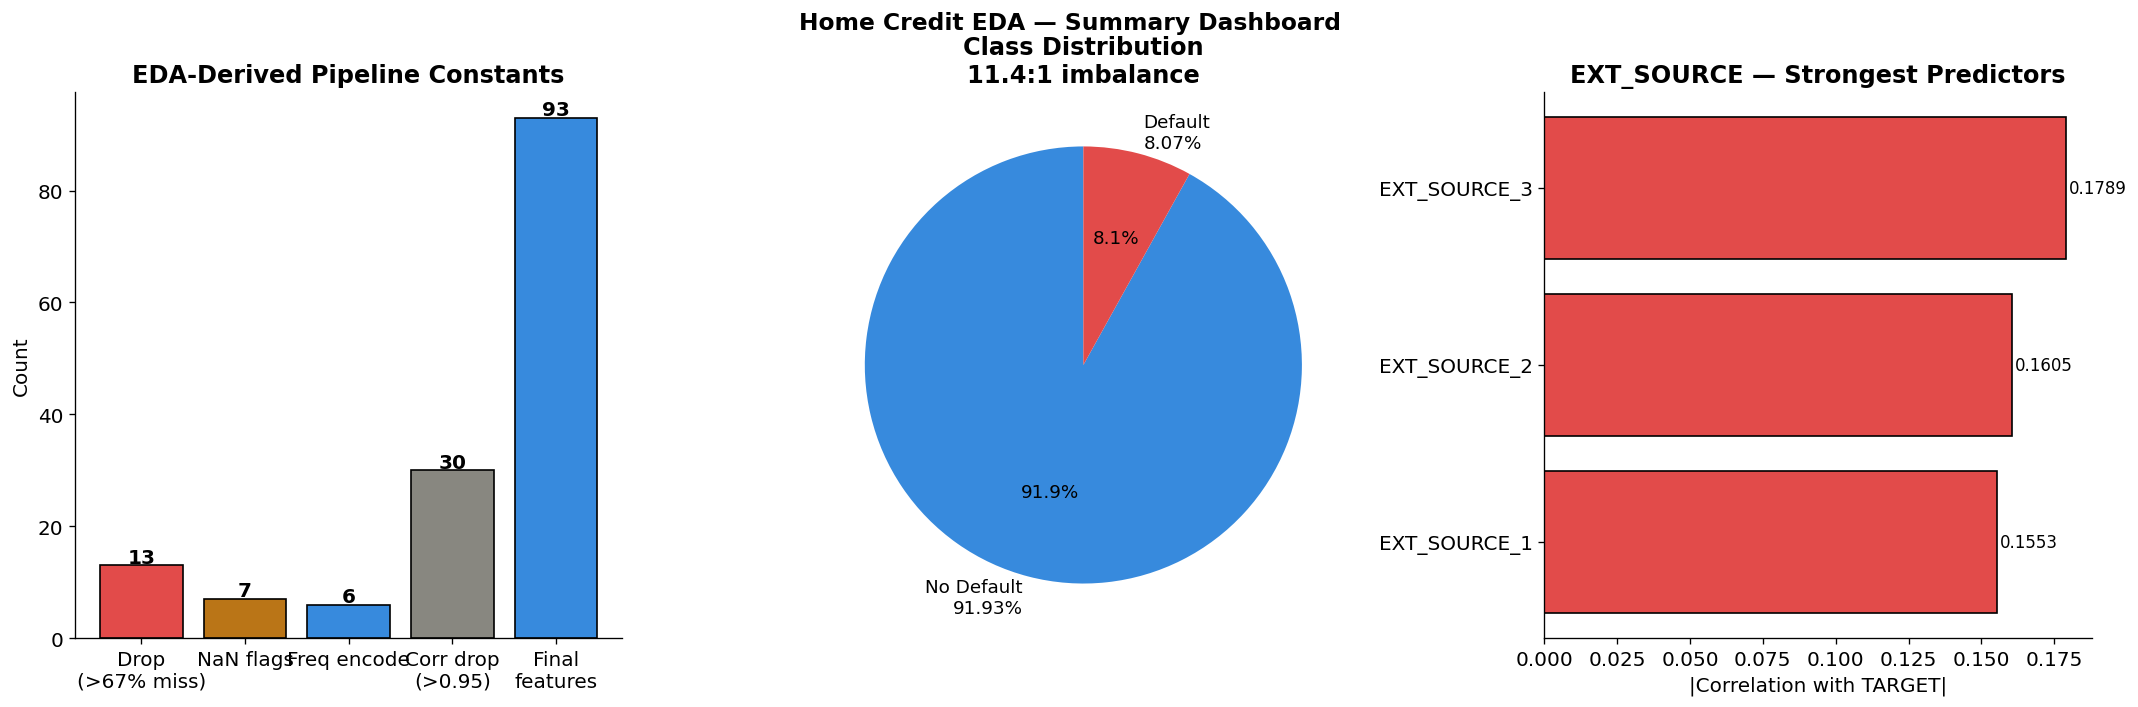

Saved: 10_conclusions/eda_summary.png

HOME CREDIT EDA COMPLETE ✅


In [12]:
print('=' * 65)
print('FINRISKGUARD — EDA CONCLUSIONS')
print('Home Credit Default Risk Dataset')
print('=' * 65)

# ── Data-driven constants ─────────────────────────────────────────────────────
HIGH_MISSING_THRESHOLD = 0.67           # EXT_SOURCE_1 has 65.99% → must be > 0.66
DAYS_EMPLOYED_ANOMALY  = 365243         # Known anomaly — 55,374 rows
ANOMALY_MEDIAN         = -1648          # median of normal DAYS_EMPLOYED

NAN_FLAG_COLS = [
    'EXT_SOURCE_1',          # 65.99% missing — NaN = missing risk score signal
    'EXT_SOURCE_2',          # 0.27% missing
    'EXT_SOURCE_3',          # 19.83% missing
    'AMT_GOODS_PRICE',       # 0.09% missing
    'AMT_ANNUITY',           # 0.004% missing
    'OWN_CAR_AGE',           # 66.35% missing (only when FLAG_OWN_CAR=Y)
    'DAYS_LAST_PHONE_CHANGE',# 0.001% missing
]

FREQ_ENCODE_COLS = [
    'ORGANIZATION_TYPE', 'OCCUPATION_TYPE',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS',
]

CORR_DROP_THRESHOLD = 0.95   # drops ~30 building AVG/MODE/MEDI columns
TOP_K_FEATURES      = 60     # per method, union → ~93 final

HIGH_RISK_INCOME_TYPES = ['Maternity leave', 'Unemployed']  # >30% default
HIGH_RISK_EDUCATION    = ['Lower secondary']                 # 10.9% default
HIGH_RISK_HOUSING      = ['Rented apartment', 'With parents'] # >10% default

print(f"""
[1] DATASET SUMMARY
  Train transactions : 307,511
  Train features     : 122
  Default rate       : 8.07% (24,825 default / 282,686 no default)
  Imbalance ratio    : 11.4:1
  Test transactions  : 48,744
  Supplementary rows : ~58M total across 6 tables

[2] MISSING VALUES
  Columns with missing   : 67 / 122
  DROP threshold         : >{HIGH_MISSING_THRESHOLD*100:.0f}% → 13 columns removed
  NaN flag columns       : {len(NAN_FLAG_COLS)} columns (missingness = signal)
  {NAN_FLAG_COLS}

[3] CLASS IMBALANCE STRATEGY
  XGBoost  → scale_pos_weight = 11
  LightGBM → is_unbalance = True
  CatBoost → auto_class_weights = 'Balanced'

[4] DAYS_EMPLOYED ANOMALY
  Value={DAYS_EMPLOYED_ANOMALY} → 55,374 rows (18.0%)
  Strategy: replace with median={ANOMALY_MEDIAN} + add DAYS_EMPLOYED_ANOM flag
  Anomaly default rate: {df.loc[df['DAYS_EMPLOYED']==DAYS_EMPLOYED_ANOMALY, 'TARGET'].mean()*100:.2f}% vs normal: {df.loc[df['DAYS_EMPLOYED']!=DAYS_EMPLOYED_ANOMALY, 'TARGET'].mean()*100:.2f}%

[5] TOP PREDICTORS (correlation with TARGET)
  EXT_SOURCE_3        : {df['EXT_SOURCE_3'].corr(df['TARGET']):.4f}
  EXT_SOURCE_2        : {df['EXT_SOURCE_2'].corr(df['TARGET']):.4f}
  EXT_SOURCE_1        : {df['EXT_SOURCE_1'].corr(df['TARGET']):.4f}
  DAYS_BIRTH (age)    : {df['DAYS_BIRTH'].corr(df['TARGET']):.4f}
  DAYS_EMPLOYED       : {df['DAYS_EMPLOYED'].corr(df['TARGET']):.4f}
  FE ext_mean (combo) : strongest combination feature

[6] KEY CATEGORICAL INSIGHTS
  Maternity leave     : ~40.0% default (highest income type)
  Unemployed          : ~36.0% default
  Lower secondary edu : ~10.9% default
  Rented apartment    : ~12.3% default
  Male gender         : ~10.1% vs female 7.0%
  Cash loans          : ~8.4% vs revolving 5.5%

[7] FEATURE ENGINEERING PLAN
  EXT_SOURCE combinations  : mean, min, max, std, products → 8 features
  Age & employment         : FE_age_years, FE_age_group, FE_employment_ratio → 4 features
  Amount ratios            : credit/income, annuity/income, annuity/credit, goods → 6 features
  Frequency encoding       : 6 categorical columns → 6 freq features
  Bureau agg               : 12 features (DPD, credit sum, overdue, etc.)
  Previous app agg         : 9 features (approved rate key signal)
  POS CASH agg             : 6 features
  Installments agg         : 7 features (late rate key signal)
  Credit card agg          : 9 features (utilization key signal)
  Total FE features        : ~67

[8] PREPROCESSING PIPELINE
  1. Drop >67% missing columns (13 dropped)
  2. Fix DAYS_EMPLOYED anomaly + flag
  3. Add NaN flag features (7 columns)
  4. Impute numerical with median (49 columns)
  5. Impute categorical with mode (5 columns)
  6. OrdinalEncoder for categorical (15 columns)

[9] FEATURE SELECTION
  Correlation filter     : 0.95 threshold → ~30 dropped (building AVG/MODE/MEDI)
  MI selection           : top 60
  XGBoost importance     : top 60
  Union strategy         : ~93 final features
  Reason for union       : MI catches statistical, XGB catches model-relevant
""")

# ── Summary figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

summary_labels = ['Drop\n(>67% miss)', 'NaN flags', 'Freq encode', 'Corr drop\n(>0.95)', 'Final\nfeatures']
summary_counts = [13, len(NAN_FLAG_COLS), len(FREQ_ENCODE_COLS), 30, 93]
colors_s = [PALETTE['default'], PALETTE['highlight'], PALETTE['ok'], PALETTE['neutral'], PALETTE['ok']]
axes[0].bar(summary_labels, summary_counts, color=colors_s, edgecolor='black')
axes[0].set_title('EDA-Derived Pipeline Constants', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(summary_counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].pie(
    [len(ok), len(default)],
    labels=['No Default\n91.93%', 'Default\n8.07%'],
    colors=[PALETTE['ok'], PALETTE['default']],
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[1].set_title(f'Class Distribution\n11.4:1 imbalance', fontweight='bold')

ext_corrs = {c: abs(df[c].corr(df['TARGET'])) for c in ext_cols}
axes[2].barh(list(ext_corrs.keys()), list(ext_corrs.values()),
             color=PALETTE['default'], edgecolor='black')
axes[2].set_xlabel('|Correlation with TARGET|')
axes[2].set_title('EXT_SOURCE — Strongest Predictors', fontweight='bold')
for i, v in enumerate(ext_corrs.values()):
    axes[2].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Home Credit EDA — Summary Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '10_conclusions' / 'eda_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 10_conclusions/eda_summary.png')

print('\n' + '=' * 65)
print('HOME CREDIT EDA COMPLETE ✅')
print('=' * 65)
